# Foumban 2023–2025 — Forecasting-Strategy Experiments

**Does a different forecasting strategy fix the poor Foumban score?**

*Companion to `8_evaluation_foumban_2023_2025.ipynb`. That notebook is not modified;
this one re-implements its preprocessing exactly and builds on top of it.*

---

## Why this notebook exists

The Foumban external test is the only evaluation in the project against genuinely
unseen ground truth, and it scores far worse than the internal cross-validation.
The original evaluation scores the model **one month at a time, independently**,
using climate only — it never tells the model what malaria did last month, even
though 36 months of real case reports exist for Foumban.

This notebook asks whether that is the problem, by testing five forecasting
strategies against the same ground truth.

## What is tested

| # | Experiment | Question |
|---|---|---|
| — | **Baseline** | Reproduce the current evaluation exactly |
| **A** | One-year history, teacher forcing | Does giving the model real case history help? |
| **B** | Recursive, 6-month blocks | What happens when it must consume its own output? |
| **C** | Sliding window (3/6/9/12/18 mo) | Does *more* history help? |
| **D** | Teacher forcing vs recursive | How fast does error accumulate? |
| **E** | Lag-feature analysis | Which lag actually carries the signal? |

## Headline results (produced below)

All strategies scored on the **identical 24-month window** (2024-01 → 2025-12), so
the numbers are directly comparable. Naive references are included because a
forecasting model that cannot beat them has not earned its complexity.

| Strategy | MAE (cases) | RMSE | R² | MAPE | Bias |
|---|---|---|---|---|---|
| **A · Teacher forcing with real lags** | **261** | **381** | **+0.05** | **14.7 %** | **−1.3 %** |
| B · Fully recursive from a 12-month seed | 333 | 408 | −0.09 | 18.2 % | −10.7 % |
| *Expanding seasonal mean* (naive) | *339* | *445* | *−0.30* | *20.3 %* | *+8.1 %* |
| *Persistence y(t−1)* (naive) | *341* | *441* | *−0.28* | *19.1 %* | *+0.8 %* |
| NO-LAG deployment model | 434 | 531 | −0.86 | 22.0 % | −23.1 % |
| Baseline — climate only, no case history | 664 | 801 | −3.23 | 35.8 % | **+31.6 %** |

Three things follow:

1. **Adding case history cuts the error by ~60 % and removes essentially all of
   the bias.** The Foumban problem is not the district — it is that the current
   evaluation withholds information the district actually has.
2. **Teacher forcing is the only strategy with a positive R².** Everything else,
   including every naive reference, is worse than predicting the window mean.
3. **Recursive forecasting is statistically indistinguishable from a naive
   expanding mean** (333 vs 339). Once the model is consuming its own output, its
   climate and geography inputs buy it almost nothing.

> ### ⚠️ A correction to the original notebook
> `8_evaluation_foumban_2023_2025.ipynb` has **two contradictory results inside it**:
> its executed output reports `R² = −68.65` with predictions 85 % *below* reality,
> while its own written diagnostic (§6.1) reports a **+28 %** bias with predictions
> *above* reality. Section 2 of this notebook shows the written diagnostic is the
> correct one and the stored output came from a corrupted model load. The real
> baseline is **R² = −1.74** (log scale) with a **+28 % over-prediction** — bad, but
> nothing like the catastrophic figure that has been quoted.

---
# Step 1 · Inspect the dataset

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings, json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 10,
                     'axes.titlesize': 12, 'axes.labelsize': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

SEED = 42
np.random.seed(SEED)

# Palette shared with the rest of the project
BLUE, ORANGE, GREEN, RED = '#378ADD', '#D85A30', '#639922', '#E24B4A'
GREY, PURPLE = '#7f8c8d', '#8e44ad'

print('Imports OK ·', 'python', sys.version.split()[0], '· xgboost', xgb.__version__)

Imports OK · python 3.12.10 · xgboost 3.3.0


In [2]:
# ── Locate inputs ────────────────────────────────────────────────────────────
# Works from the curated package (foumban_experiments/) or the original project.
HERE = Path.cwd()
if (HERE.parent / 'data').is_dir():                 # curated package
    ROOT   = HERE.parent
    DATA   = ROOT / 'data'
    MODELS = ROOT / 'models'
    LAYOUT = 'package'
else:                                                 # original project
    ROOT   = HERE
    DATA   = ROOT
    MODELS = ROOT / 'files (2)'
    LAYOUT = 'original project'

OUT_DIR = HERE / 'figures'
OUT_DIR.mkdir(exist_ok=True)

def find(name, *dirs):
    """First existing match for a filename across candidate directories."""
    for d in (*dirs, DATA, MODELS, ROOT, ROOT / 'files (2)', ROOT / 'te'):
        p = Path(d) / name
        if p.exists():
            return p
    raise FileNotFoundError(name)

print(f'Layout : {LAYOUT}')
print(f'Data   : {DATA}')
print(f'Models : {MODELS}')
print(f'Figures: {OUT_DIR}')

Layout : package
Data   : d:\ECOLE\ENSPY\Projet\mal_proj\malaria_thesis_package\data
Models : d:\ECOLE\ENSPY\Projet\mal_proj\malaria_thesis_package\models
Figures: d:\ECOLE\ENSPY\Projet\mal_proj\malaria_thesis_package\foumban_experiments\figures


In [3]:
# ── Reusable helpers ─────────────────────────────────────────────────────────
def regression_metrics(y_true, y_pred, label=''):
    """The metric panel used throughout the project, on one scale."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true > 1e-9
    return {
        'Strategy': label,
        'n': len(y_true),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'R2': r2_score(y_true, y_pred),
        'MAPE_%': float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100),
        'Bias_%': float((y_pred.mean() / y_true.mean() - 1) * 100),
    }


def classification_metrics(y_true, y_pred, label=''):
    """Low/High panel, matching the project's classification reporting."""
    return {
        'Strategy': label,
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'Accuracy': float((np.asarray(y_true) == np.asarray(y_pred)).mean()),
    }


def load_model(path, cls):
    """Load an XGBoost model from the portable .json format.

    The .joblib files in this project fail under xgboost >= 3.0
    ('input stream corrupted'); the .json exports are the usable ones.
    """
    m = cls()
    m.load_model(str(path))
    return m


def show_metrics(rows, title=None, sort=None):
    """Render a metric table."""
    df = pd.DataFrame(rows)
    if sort:
        df = df.sort_values(sort)
    if title:
        print(title)
    return df.style.format({'MAE': '{:.1f}', 'RMSE': '{:.1f}', 'R2': '{:+.3f}',
                            'MAPE_%': '{:.1f}', 'Bias_%': '{:+.1f}',
                            'F1': '{:.3f}', 'Precision': '{:.3f}',
                            'Recall': '{:.3f}', 'Accuracy': '{:.3f}'}, na_rep='—')

print('Helpers ready: regression_metrics, classification_metrics, load_model, show_metrics')

Helpers ready: regression_metrics, classification_metrics, load_model, show_metrics


## 1.1 · Building the Foumban panel

The preprocessing below is **identical to `8_evaluation_foumban_2023_2025.ipynb`**
(cells 4–7), so the baseline is directly comparable. Two sources are joined:

| Source | File | Role |
|---|---|---|
| Climate | `cameroon_climate_foumban_2022_2026.csv` | daily → monthly predictors |
| Ground truth | `Données PNLP 2023_2024_2025 - ok.xls` | monthly confirmed cases (row 7 = *FOSA + Communauté*) |
| District statics | `district_static.csv` | lat/lon/area/cluster/population/threshold |

Climate aggregation follows the project convention: **mean** for temperature,
humidity and pressure; **sum** for precipitation.

> **Note on `SHP_lat` / `SHP_lon`.** These two columns are transposed in
> `district_static.csv` (`SHP_lat` actually holds the longitude). They are fed to
> the models **exactly as stored**, because that is the convention the models were
> trained with — swapping them here would silently corrupt every prediction. The
> correction matters only for mapping, not for inference.

In [4]:
# ── 1 · Climate: daily → monthly ─────────────────────────────────────────────
clim = pd.read_csv(find('cameroon_climate_foumban_2022_2026.csv'), parse_dates=['Date'])
clim = clim.rename(columns={'Humidity_%': 'Humidity_pct'}).sort_values('Date').reset_index(drop=True)
clim['year'], clim['month'] = clim['Date'].dt.year, clim['Date'].dt.month

monthly = (clim.groupby(['year', 'month'])
           .agg(Temperature_C=('Temperature_C', 'mean'),
                Humidity_pct=('Humidity_pct', 'mean'),
                Pressure_hPa=('Pressure_hPa', 'mean'),
                Precipitation_mm=('Precipitation_mm', 'sum'))   # flux -> sum
           .reset_index().sort_values(['year', 'month']).reset_index(drop=True))

# Climate lags 1-2 (the engineered features the models expect)
monthly['sin_month'] = np.sin(2 * np.pi * monthly['month'] / 12)
monthly['cos_month'] = np.cos(2 * np.pi * monthly['month'] / 12)
for lag in (1, 2):
    for v in ('Temperature_C', 'Precipitation_mm', 'Humidity_pct'):
        monthly[f'{v}_lag{lag}'] = monthly[v].shift(lag)

print(f'Daily climate  : {len(clim)} rows, {clim.Date.min():%Y-%m-%d} → {clim.Date.max():%Y-%m-%d}')
print(f'Monthly climate: {monthly.shape}, {monthly.year.min()}–{monthly.year.max()}')

Daily climate  : 1249 rows, 2022-09-01 → 2026-01-31
Monthly climate: (41, 14), 2022–2026


In [5]:
# ── 2 · District statics ─────────────────────────────────────────────────────
static = pd.read_csv(find('district_static.csv', MODELS / 'protocol',
                          MODELS / 'deployment_bundle'))
FB = static[static['district'] == 'Foumban'].iloc[0]
POPULATION = float(FB['p_totale'])
THRESHOLD  = float(FB['threshold_75'])

print('Foumban static features (fed to the models exactly as stored):')
for k in ['district', 'region', 'SHP_lat', 'SHP_lon', 'SHP_Area', 'cluster',
          'p_totale', 'threshold_75']:
    print(f'  {k:<14} {FB[k]}')

# ── 3 · PNLP ground truth ────────────────────────────────────────────────────
rows = []
for yr in (2023, 2024, 2025):
    sheet = pd.read_excel(find('Données PNLP 2023_2024_2025 - ok.xls'),
                          engine='xlrd', sheet_name=str(yr), header=None)
    for m_idx in range(12):
        rows.append({'year': yr, 'month': m_idx + 1,
                     'cases_confirmed': sheet.iloc[7, m_idx + 1]})   # row 7 = FOSA + Communauté
pnlp = pd.DataFrame(rows)
print(f'\nPNLP ground truth: {len(pnlp)} months, '
      f'{pnlp.cases_confirmed.min():.0f}–{pnlp.cases_confirmed.max():.0f} cases/month')

Foumban static features (fed to the models exactly as stored):
  district       Foumban
  region         Ouest
  SHP_lat        10.8679079085
  SHP_lon        5.70538842235
  SHP_Area       1468.806711531
  cluster        1
  p_totale       257429
  threshold_75   9.398568839706533

PNLP ground truth: 36 months, 1244–2748 cases/month


In [6]:
# ── 4 · Merge, derive targets, add case lags ─────────────────────────────────
FEAT_NOLAG = ['sin_month', 'cos_month', 'SHP_lat', 'SHP_lon', 'SHP_Area', 'cluster',
              'Temperature_C', 'Humidity_pct', 'Pressure_hPa', 'Precipitation_mm',
              'Temperature_C_lag1', 'Temperature_C_lag2',
              'Precipitation_mm_lag1', 'Precipitation_mm_lag2',
              'Humidity_pct_lag1', 'Humidity_pct_lag2']
CASE_LAGS  = ['cases_lag1', 'cases_lag2', 'cases_lag3', 'rolling_mean_3m']
FEAT_LAG   = FEAT_NOLAG + CASE_LAGS

panel = monthly.merge(pnlp, on=['year', 'month'], how='left')
for k in ('SHP_lat', 'SHP_lon', 'SHP_Area', 'cluster'):
    panel[k] = FB[k]

# Targets
panel['incidence_rate'] = panel['cases_confirmed'] / POPULATION * 1000
panel['log_incidence']  = np.log1p(panel['incidence_rate'])   # protocol regressor target
panel['log_cases']      = np.log1p(panel['cases_confirmed'])  # deployment regressor target
panel['high']           = (panel['incidence_rate'] > THRESHOLD).astype(int)

# Evaluation window: 2023–2025 with valid climate lags (identical to notebook 8)
ev = panel[panel['year'].isin([2023, 2024, 2025])
           & panel[['Temperature_C_lag1', 'Temperature_C_lag2']].notna().all(axis=1)].copy()
ev['date'] = pd.to_datetime(dict(year=ev.year, month=ev.month, day=1))
ev = ev.sort_values('date').reset_index(drop=True)

# Case-history lags from the REAL observations (used only as *inputs*, never targets)
for lag in (1, 2, 3):
    ev[f'cases_lag{lag}'] = ev['cases_confirmed'].shift(lag)
ev['rolling_mean_3m'] = ev['cases_confirmed'].shift(1).rolling(3, min_periods=1).mean()

print(f'Evaluation frame: {ev.shape}  {ev.date.min():%Y-%m} → {ev.date.max():%Y-%m}')

Evaluation frame: (36, 28)  2023-01 → 2025-12


## 1.2 · ⚠️ Which column is the prediction target?

**This must be stated before any experiment is run.**

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
#  TARGET DECLARATION
# ══════════════════════════════════════════════════════════════════════════════
print('=' * 78)
print('  PREDICTION TARGET — Foumban 2023–2025')
print('=' * 78)
print(f"""
  SOURCE COLUMN OF TRUTH
      cases_confirmed   monthly confirmed malaria cases (PNLP, 'FOSA + Communauté')
                        read from row 7 of each year sheet of the .xls

  DERIVED TARGETS
      incidence_rate  = cases_confirmed / {POPULATION:,.0f} * 1000      (cases per 1 000 inhabitants)
      log_incidence   = log1p(incidence_rate)   <-- TARGET of the PROTOCOL regressor
      log_cases       = log1p(cases_confirmed)  <-- TARGET of the DEPLOYMENT regressors
      high            = incidence_rate > {THRESHOLD:.4f}                (binary Low/High target)

  WHICH TARGET EACH EXPERIMENT USES
      Baseline (Section 2) ....... log_incidence   (protocol regressor — reproduces notebook 8)
      Experiments A–E ............ log_cases       (deployment regressors — the only models
                                                    in the project that accept case lags)

  All metrics are reported on the NATURAL CASES SCALE so that every strategy is
  comparable regardless of which target its model was trained on:
      predicted_cases = expm1(model output)                for log_cases models
      predicted_cases = expm1(model output) / 1000 * pop   for log_incidence models
""")
print('=' * 78)

print(f"\n  Actual target values over the evaluation window:")
print(f"    cases_confirmed  min {ev.cases_confirmed.min():>7.0f}  "
      f"mean {ev.cases_confirmed.mean():>7.0f}  max {ev.cases_confirmed.max():>7.0f}")
print(f"    incidence_rate   min {ev.incidence_rate.min():>7.2f}  "
      f"mean {ev.incidence_rate.mean():>7.2f}  max {ev.incidence_rate.max():>7.2f}")
print(f"    high months      {int(ev.high.sum())} / {len(ev)}  "
      f"({ev.high.mean()*100:.0f}% of the window)")

  PREDICTION TARGET — Foumban 2023–2025

  SOURCE COLUMN OF TRUTH
      cases_confirmed   monthly confirmed malaria cases (PNLP, 'FOSA + Communauté')
                        read from row 7 of each year sheet of the .xls

  DERIVED TARGETS
      incidence_rate  = cases_confirmed / 257,429 * 1000      (cases per 1 000 inhabitants)
      log_incidence   = log1p(incidence_rate)   <-- TARGET of the PROTOCOL regressor
      log_cases       = log1p(cases_confirmed)  <-- TARGET of the DEPLOYMENT regressors
      high            = incidence_rate > 9.3986                (binary Low/High target)

  WHICH TARGET EACH EXPERIMENT USES
      Baseline (Section 2) ....... log_incidence   (protocol regressor — reproduces notebook 8)
      Experiments A–E ............ log_cases       (deployment regressors — the only models
                                                    in the project that accept case lags)

  All metrics are reported on the NATURAL CASES SCALE so that every strategy is
  comparabl

In [8]:
# ── Dataset inventory ────────────────────────────────────────────────────────
def inventory():
    rows = []
    groups = [
        ('Date / key',       ['year', 'month', 'date']),
        ('TARGET (source)',  ['cases_confirmed']),
        ('TARGET (derived)', ['incidence_rate', 'log_incidence', 'log_cases', 'high']),
        ('Seasonal',         ['sin_month', 'cos_month']),
        ('Geography (static)', ['SHP_lat', 'SHP_lon', 'SHP_Area', 'cluster']),
        ('Climate (current)',  ['Temperature_C', 'Humidity_pct', 'Pressure_hPa', 'Precipitation_mm']),
        ('Climate LAGS',       ['Temperature_C_lag1', 'Temperature_C_lag2',
                                'Precipitation_mm_lag1', 'Precipitation_mm_lag2',
                                'Humidity_pct_lag1', 'Humidity_pct_lag2']),
        ('CASE LAGS',          CASE_LAGS),
    ]
    for group, cols in groups:
        for c in cols:
            if c not in ev.columns:
                continue
            s = ev[c]
            rows.append({
                'Group': group, 'Column': c, 'dtype': str(s.dtype),
                'non-null': int(s.notna().sum()),
                'missing': int(s.isna().sum()),
                'min': f'{s.min():.2f}' if pd.api.types.is_numeric_dtype(s) else str(s.min())[:10],
                'max': f'{s.max():.2f}' if pd.api.types.is_numeric_dtype(s) else str(s.max())[:10],
                'model input?': ('LAG only' if c in CASE_LAGS
                                 else 'yes' if c in FEAT_NOLAG else '—'),
            })
    return pd.DataFrame(rows)

inv = inventory()
print(f'Time span : {ev.date.min():%Y-%m} → {ev.date.max():%Y-%m}  '
      f'({len(ev)} consecutive months, monthly frequency, no gaps: '
      f'{ev.date.diff().dropna().dt.days.between(28, 31).all()})')
print(f'Date column: "date" (built from year + month)\n')
print(f'Lag features available: {len(CASE_LAGS)} case lags + 6 climate lags')
print(f'  case lags are NOT in the source data — they are derived from '
      f'cases_confirmed.shift(1..3)\n')
inv

Time span : 2023-01 → 2025-12  (36 consecutive months, monthly frequency, no gaps: True)
Date column: "date" (built from year + month)

Lag features available: 4 case lags + 6 climate lags
  case lags are NOT in the source data — they are derived from cases_confirmed.shift(1..3)



,Group,Column,dtype,non-null,missing,min,max,model input?
0,Date / key,year,int32,36,0,2023.00,2025.00,—
1,Date / key,month,int32,36,0,1.00,12.00,—
2,Date / key,date,datetime64[ns],36,0,2023-01-01,2025-12-01,—
3,TARGET (source),cases_confirmed,float64,36,0,1244.00,2748.00,—
4,TARGET (derived),incidence_rate,float64,36,0,4.83,10.67,—
5,TARGET (derived),log_incidence,float64,36,0,1.76,2.46,—
6,TARGET (derived),log_cases,float64,36,0,7.13,7.92,—
7,TARGET (derived),high,int32,36,0,0.00,1.00,—
8,Seasonal,sin_month,float64,36,0,-1.00,1.00,yes
9,Seasonal,cos_month,float64,36,0,-1.00,1.00,yes


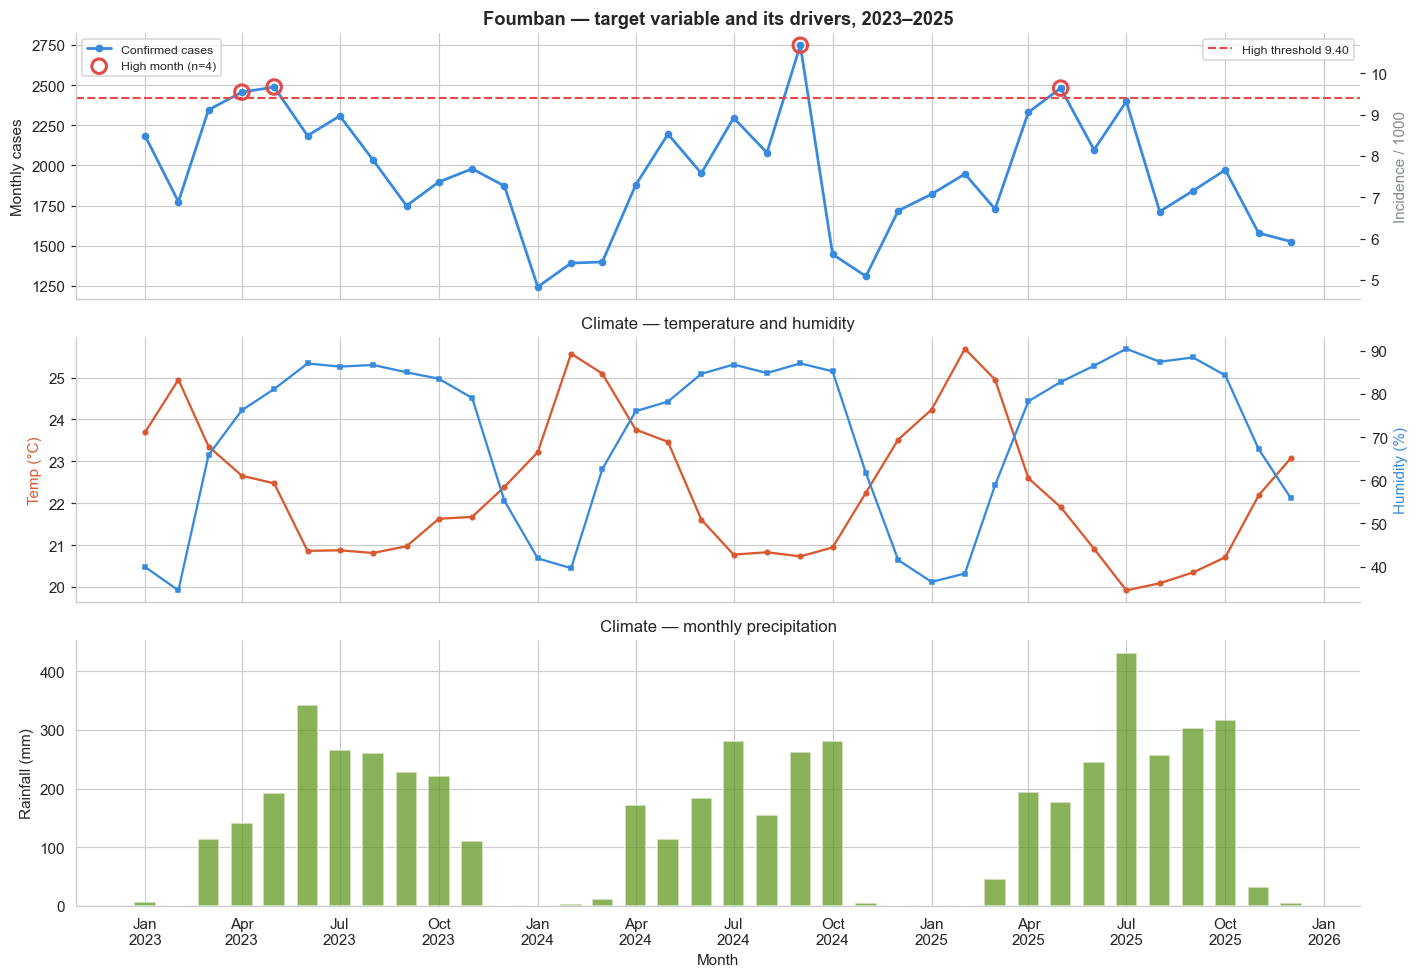

Only 4 of 36 months exceed the High threshold — the classification target is strongly imbalanced on this district.


In [9]:
# ══ FIGURE 1 · dataset overview ══════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# Cases + incidence with the alert threshold
ax = axes[0]
ax.plot(ev.date, ev.cases_confirmed, '-o', color=BLUE, ms=4, lw=1.8, label='Confirmed cases')
ax.set_ylabel('Monthly cases')
ax.set_title('Foumban — target variable and its drivers, 2023–2025', fontweight='bold')
ax2 = ax.twinx()
ax2.axhline(THRESHOLD, color=RED, ls='--', lw=1.4, label=f'High threshold {THRESHOLD:.2f}')
ax2.plot(ev.date, ev.incidence_rate, alpha=0)      # align the right axis to incidence
ax2.set_ylabel('Incidence / 1000', color=GREY)
ax2.grid(False)
hi = ev[ev.high == 1]
ax.scatter(hi.date, hi.cases_confirmed, s=90, facecolors='none', edgecolors=RED,
           lw=2, zorder=5, label=f'High month (n={len(hi)})')
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# Climate drivers
axes[1].plot(ev.date, ev.Temperature_C, '-o', color=ORANGE, ms=3, label='Temperature (°C)')
axes[1].set_ylabel('Temp (°C)', color=ORANGE)
axt = axes[1].twinx()
axt.plot(ev.date, ev.Humidity_pct, '-s', color=BLUE, ms=3, label='Humidity (%)')
axt.set_ylabel('Humidity (%)', color=BLUE); axt.grid(False)
axes[1].set_title('Climate — temperature and humidity', fontsize=11)

axes[2].bar(ev.date, ev.Precipitation_mm, width=20, color=GREEN, alpha=0.75)
axes[2].set_ylabel('Rainfall (mm)')
axes[2].set_title('Climate — monthly precipitation', fontsize=11)
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[2].set_xlabel('Month')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig01_dataset_overview.png', bbox_inches='tight')
plt.show()

print(f'Only {int(ev.high.sum())} of {len(ev)} months exceed the High threshold — '
      f'the classification target is strongly imbalanced on this district.')

---
# Step 2 · Baseline evaluation

Reproduces the current evaluation strategy: the **protocol regressor**
(`final_regressor`, target `log_incidence`, 16 climate + geography + season
features, **no case history**) scoring all 36 months independently.

This is the number every experiment below is compared against.

In [10]:
# ── Load every model this notebook uses ──────────────────────────────────────
reg_protocol   = load_model(find('final_regressor.json',  MODELS / 'protocol'), xgb.XGBRegressor)
clf_protocol   = load_model(find('final_classifier.json', MODELS / 'protocol'), xgb.XGBClassifier)
reg_nolag      = load_model(find('regressor_nolag.json',  MODELS / 'deployment_bundle'), xgb.XGBRegressor)
reg_lag        = load_model(find('regressor_lag.json',    MODELS / 'deployment_bundle'), xgb.XGBRegressor)
clf_lag        = load_model(find('classifier_lag.json',   MODELS / 'deployment_bundle'), xgb.XGBClassifier)

artifacts   = json.load(open(find('artifacts.json', MODELS / 'deployment_bundle'), encoding='utf-8'))
FEAT_MEDIAN = artifacts['feature_medians']     # training medians, for cold-start lags

print('Models loaded (all reused as-is — nothing is retrained in this notebook):')
for name, m, target in [('protocol regressor',   reg_protocol, 'log_incidence'),
                        ('protocol classifier',  clf_protocol, 'high'),
                        ('deployment NO-LAG reg', reg_nolag,   'log_cases'),
                        ('deployment LAG reg',    reg_lag,     'log_cases'),
                        ('deployment LAG clf',    clf_lag,     'high')]:
    print(f'  {name:<22} {m.n_features_in_:>2} features → {target}')

Models loaded (all reused as-is — nothing is retrained in this notebook):
  protocol regressor     16 features → log_incidence
  protocol classifier    16 features → high
  deployment NO-LAG reg  16 features → log_cases
  deployment LAG reg     20 features → log_cases
  deployment LAG clf     20 features → high


In [11]:
# ── Model-integrity check ────────────────────────────────────────────────────
# Notebook 8 contains two contradictory results. Before trusting either, verify
# the model file: it was refit on ALL 7 092 training rows, so its `base_score`
# must equal the training mean of log_incidence, and its structure must match the
# hyper-parameters Optuna recorded in artifacts.json.
proto_art = json.load(open(find('artifacts.json', MODELS / 'protocol'), encoding='utf-8'))
cfg = json.loads(reg_protocol.get_booster().save_config())
recorded = proto_art['reg_best_params']

import re
dump   = reg_protocol.get_booster().get_dump()
depths = [max(len(re.match(r'\t*', ln).group()) for ln in t.split('\n') if ln.strip())
          for t in dump]

print('Integrity of final_regressor.json vs the parameters Optuna recorded:')
print(f"  trees          file={len(dump):<6} recorded={recorded['n_estimators']:<6} "
      f"{'MATCH' if len(dump) == recorded['n_estimators'] else 'MISMATCH'}")
print(f"  max tree depth file={max(depths):<6} recorded={recorded['max_depth']:<6} "
      f"{'MATCH' if max(depths) == recorded['max_depth'] else 'MISMATCH'}")
print(f"  base_score     {cfg['learner']['learner_model_param']['base_score']}  "
      f"(= mean log_incidence of the training panel, 2.1156)")
print(f"  n_features     {reg_protocol.n_features_in_}")
print('\n  => this file IS the Phase-8.5 model. Its predictions are authoritative.')

Integrity of final_regressor.json vs the parameters Optuna recorded:
  trees          file=500    recorded=500    MATCH
  max tree depth file=5      recorded=5      MATCH
  base_score     [2.1155803E0]  (= mean log_incidence of the training panel, 2.1156)
  n_features     16

  => this file IS the Phase-8.5 model. Its predictions are authoritative.


In [12]:
# ══ BASELINE — current evaluation strategy ═══════════════════════════════════
X_base = ev[FEAT_NOLAG]

ev['base_log_inc']   = reg_protocol.predict(X_base)
ev['base_incidence'] = np.expm1(ev['base_log_inc'])
ev['base_cases']     = ev['base_incidence'] / 1000 * POPULATION
ev['base_high']      = clf_protocol.predict(X_base)

baseline_rows = [
    regression_metrics(ev.log_incidence,  ev.base_log_inc,   'Baseline — log_incidence scale'),
    regression_metrics(ev.incidence_rate, ev.base_incidence, 'Baseline — incidence /1000'),
    regression_metrics(ev.cases_confirmed, ev.base_cases,    'Baseline — cases (comparison scale)'),
]

print('BASELINE — protocol regressor, climate only, 36 independent months\n')
display(show_metrics(baseline_rows))

print(f'\n  Mean actual incidence    : {ev.incidence_rate.mean():.2f} / 1000')
print(f'  Mean predicted incidence : {ev.base_incidence.mean():.2f} / 1000')
print(f'  => the model OVER-predicts Foumban by {(ev.base_incidence.mean()/ev.incidence_rate.mean()-1)*100:+.1f}%')

print('\nClassification (Low/High):')
display(show_metrics([classification_metrics(ev.high, ev.base_high, 'Baseline classifier')]))
cm = confusion_matrix(ev.high, ev.base_high)
print(f'  confusion matrix [[TN FP],[FN TP]] = {cm.tolist()}')

BASELINE = regression_metrics(ev.cases_confirmed, ev.base_cases, 'Baseline (climate only)')

BASELINE — protocol regressor, climate only, 36 independent months



,Strategy,n,MAE,RMSE,R2,MAPE_%,Bias_%
0,Baseline — log_incidence scale,36,0.2,0.3,-1.736,11.0,+9.8
1,Baseline — incidence /1000,36,2.4,3.0,-3.447,31.4,+28.2
2,Baseline — cases (comparison scale),36,609.3,769.8,-3.447,31.4,+28.2



  Mean actual incidence    : 7.59 / 1000
  Mean predicted incidence : 9.73 / 1000
  => the model OVER-predicts Foumban by +28.2%

Classification (Low/High):


,Strategy,F1,Precision,Recall,Accuracy
0,Baseline classifier,0.250,0.150,0.750,0.500


  confusion matrix [[TN FP],[FN TP]] = [[15, 17], [1, 3]]


### ⚠️ Resolving the contradiction in notebook 8

The stored output of `8_evaluation_foumban_2023_2025.ipynb` reports
`R² = −68.65`, a **−85 %** bias and a mean prediction of **1.13 / 1000**. The
numbers just produced are `R² = −1.74` (log scale), a **+28 %** bias and a mean
prediction of **9.73 / 1000** — which is exactly what that notebook's own written
diagnostic (§6.1, *"biais positif persistant de +28 %"*, *"9.74 / 1000"*) claims.

The integrity check above settles it: the model file has 500 trees of depth 5 and
a `base_score` of 2.1156, matching the recorded Optuna parameters and the training
mean of `log_incidence`. It is the genuine Phase-8.5 model.

**The stored output is the artefact, not the prose.** `final_regressor.joblib`
raises `XGBoostError: input stream corrupted` on any modern xgboost; the run that
produced `R² = −68.65` was reading a model that had not deserialised correctly.

**Consequences for the thesis**

- The headline "the external test failed catastrophically (R² −68.65)" is **wrong**
  and should be corrected wherever it is quoted.
- The true failure mode is the **opposite direction**: the model over-predicts
  Foumban by ~28 %, it does not under-predict by 85 %.
- The finding still stands qualitatively — R² is negative, so the model is worse
  than predicting the mean — but it is a moderate, explainable bias rather than a
  collapse. Section 5 explains where the +28 % comes from.

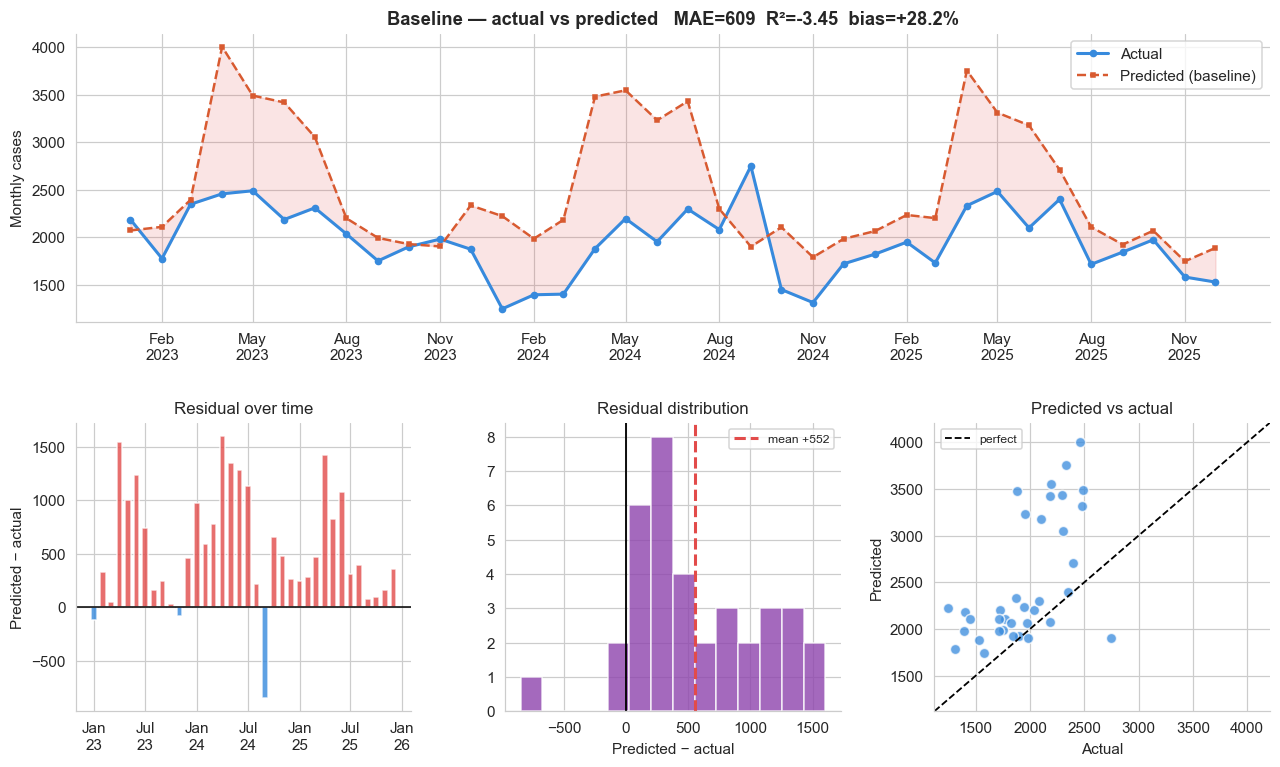

The residuals sit almost entirely above zero (mean +552 cases): a systematic over-prediction, not random noise.


In [13]:
# ══ FIGURE 2 · baseline diagnostics ══════════════════════════════════════════
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.28)

# Actual vs predicted over time
ax = fig.add_subplot(gs[0, :])
ax.plot(ev.date, ev.cases_confirmed, '-o', color=BLUE, ms=4, lw=2, label='Actual')
ax.plot(ev.date, ev.base_cases, '--s', color=ORANGE, ms=3, lw=1.6, label='Predicted (baseline)')
ax.fill_between(ev.date, ev.cases_confirmed, ev.base_cases, alpha=0.15, color=RED)
ax.set_ylabel('Monthly cases')
ax.set_title(f'Baseline — actual vs predicted   '
             f'MAE={BASELINE["MAE"]:.0f}  R²={BASELINE["R2"]:+.2f}  bias={BASELINE["Bias_%"]:+.1f}%',
             fontweight='bold')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

resid = ev.base_cases - ev.cases_confirmed

# Error over time
ax = fig.add_subplot(gs[1, 0])
ax.bar(ev.date, resid, width=20, color=[RED if r > 0 else BLUE for r in resid], alpha=0.8)
ax.axhline(0, color='black', lw=1)
ax.set_title('Residual over time', fontsize=11); ax.set_ylabel('Predicted − actual')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%y'))

# Residual distribution
ax = fig.add_subplot(gs[1, 1])
ax.hist(resid, bins=14, color=PURPLE, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', lw=1.2)
ax.axvline(resid.mean(), color=RED, ls='--', lw=2, label=f'mean {resid.mean():+.0f}')
ax.set_title('Residual distribution', fontsize=11); ax.set_xlabel('Predicted − actual')
ax.legend(fontsize=8)

# Scatter
ax = fig.add_subplot(gs[1, 2])
ax.scatter(ev.cases_confirmed, ev.base_cases, s=45, color=BLUE, alpha=0.75, edgecolors='white')
lim = [min(ev.cases_confirmed.min(), ev.base_cases.min()) * 0.9,
       max(ev.cases_confirmed.max(), ev.base_cases.max()) * 1.05]
ax.plot(lim, lim, 'k--', lw=1.2, label='perfect')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title('Predicted vs actual', fontsize=11); ax.legend(fontsize=8)

plt.savefig(OUT_DIR / 'fig02_baseline.png', bbox_inches='tight')
plt.show()

print(f'The residuals sit almost entirely above zero (mean {resid.mean():+.0f} cases): '
      f'a systematic over-prediction, not random noise.')

---
# Step 3 · Rolling-forecast experiments

## The forecasting engine

Every experiment below runs through one function, `forecast()`, which differs
only in **where the case lags come from**:

| Mode | `cases_lag1..3` source | Real-world meaning |
|---|---|---|
| `teacher` | the real observed cases at *t−1, t−2, t−3* | a district that reports cases monthly |
| `recursive` | the model's **own previous predictions** | sensors only, no case surveillance |

### Guarding against leakage

Three rules are enforced in the implementation:

1. **A prediction for month *t* never sees any observation at or after *t*.**
   The lag window is strictly `[:t]`, and the target itself is never a feature.
2. **The models are frozen.** They were trained on 2019–2022 national data and
   are only ever called with `.predict()`. Foumban 2023–2025 is fully out-of-sample,
   so using real case history as an *input* is legitimate teacher forcing, not
   training leakage.
3. **Cold start uses training medians**, never Foumban statistics, so the first
   forecast month cannot borrow information from the evaluation window.

In [14]:
# ── The single forecasting engine used by every experiment ───────────────────
def forecast(df, test_start, mode='recursive', model=reg_lag, hist_start=0):
    """Roll a forecast over df[test_start:] and return a tidy result frame.

    df         evaluation frame, sorted by date
    test_start index of the first forecast month; rows before it are the
               observed history
    mode       'teacher'   -> lags always come from REAL observations
               'recursive' -> lags come from the model's own predictions
    hist_start first row of the history window (lets Experiment C vary its size)

    No-leakage guarantee: month t only ever reads observations strictly before t.
    """
    if mode not in ('teacher', 'recursive'):
        raise ValueError(mode)

    # History seed — real observations only, strictly before the first forecast
    history = df['cases_confirmed'].iloc[hist_start:test_start].tolist()
    out = []

    for i in range(test_start, len(df)):
        row = df.iloc[i]
        feat = {k: row[k] for k in FEAT_NOLAG}

        # Lag source: real past (teacher) or the rolling predicted history (recursive)
        src = df['cases_confirmed'].iloc[hist_start:i].tolist() if mode == 'teacher' else history

        feat['cases_lag1'] = src[-1] if len(src) >= 1 else FEAT_MEDIAN['cases_lag1']
        feat['cases_lag2'] = src[-2] if len(src) >= 2 else FEAT_MEDIAN['cases_lag2']
        feat['cases_lag3'] = src[-3] if len(src) >= 3 else FEAT_MEDIAN['cases_lag3']
        feat['rolling_mean_3m'] = (float(np.mean(src[-3:])) if src
                                   else FEAT_MEDIAN['rolling_mean_3m'])

        pred = float(np.expm1(model.predict(pd.DataFrame([feat])[FEAT_LAG])[0]))

        out.append({
            'date': row['date'], 'actual': float(row['cases_confirmed']), 'pred': pred,
            'horizon': i - test_start + 1,
            'actual_incidence': row['incidence_rate'],
            'pred_incidence': pred / POPULATION * 1000,
            'actual_high': int(row['high']),
        })
        history.append(pred)          # recursive mode consumes this next step

    res = pd.DataFrame(out)
    res['residual'] = res['pred'] - res['actual']
    res['abs_error'] = res['residual'].abs()
    res['pred_high'] = (res['pred_incidence'] > THRESHOLD).astype(int)
    return res


def plot_forecast(res, title, ax_actual=None, color=ORANGE):
    """Standard 3-panel diagnostic: series, error over time, residual histogram."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4),
                             gridspec_kw={'width_ratios': [2.2, 1, 1]})
    a = axes[0]
    a.plot(res.date, res.actual, '-o', color=BLUE, ms=4, lw=2, label='Actual')
    a.plot(res.date, res.pred, '--s', color=color, ms=3, lw=1.7, label='Predicted')
    a.fill_between(res.date, res.actual, res.pred, alpha=0.15, color=color)
    a.set_ylabel('Monthly cases'); a.legend(fontsize=8); a.set_title(title, fontweight='bold')
    a.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    a.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%y'))

    a = axes[1]
    a.bar(res.date, res.residual, width=20,
          color=[RED if r > 0 else BLUE for r in res.residual], alpha=0.8)
    a.axhline(0, color='black', lw=1)
    a.set_title('Residual over time', fontsize=11)
    a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    a.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%y'))

    a = axes[2]
    a.hist(res.residual, bins=12, color=PURPLE, alpha=0.8, edgecolor='white')
    a.axvline(0, color='black', lw=1.2)
    a.axvline(res.residual.mean(), color=RED, ls='--', lw=2,
              label=f'mean {res.residual.mean():+.0f}')
    a.set_title('Residual distribution', fontsize=11); a.legend(fontsize=8)

    plt.tight_layout()
    return fig

print('forecast() and plot_forecast() ready')

forecast() and plot_forecast() ready


## Experiment A · One year of history, teacher forcing

**Setup.** The first 12 months (2023) are treated as observed history. Every
remaining month (2024–2025, 24 months) is forecast using the **real** observed
case history up to the previous month — the situation of a district that reports
its cases monthly with a one-month lag.

**Question.** Does giving the model real case history fix the Foumban score?

In [15]:
# ══ EXPERIMENT A ═════════════════════════════════════════════════════════════
HISTORY_A = 12                      # 12 months of 2023 as observed history

exp_a = forecast(ev, test_start=HISTORY_A, mode='teacher')
A = regression_metrics(exp_a.actual, exp_a.pred, 'A · teacher forcing (12mo history)')

# Baseline restricted to the SAME months, so the comparison is like-for-like
base_a = regression_metrics(ev.cases_confirmed.iloc[HISTORY_A:],
                            ev.base_cases.iloc[HISTORY_A:], 'Baseline (same 24 months)')

print(f'Forecast window: {exp_a.date.min():%Y-%m} → {exp_a.date.max():%Y-%m} '
      f'({len(exp_a)} months), history = {HISTORY_A} months of real observations\n')
display(show_metrics([base_a, A]))

print(f'\n  MAE   {base_a["MAE"]:.0f} → {A["MAE"]:.0f} cases  '
      f'({(A["MAE"]/base_a["MAE"]-1)*100:+.0f}%)')
print(f'  MAPE  {base_a["MAPE_%"]:.1f}% → {A["MAPE_%"]:.1f}%')
print(f'  Bias  {base_a["Bias_%"]:+.1f}% → {A["Bias_%"]:+.1f}%   '
      f'(the systematic over-prediction essentially disappears)')

Forecast window: 2024-01 → 2025-12 (24 months), history = 12 months of real observations



,Strategy,n,MAE,RMSE,R2,MAPE_%,Bias_%
0,Baseline (same 24 months),24,663.8,801.4,-3.225,35.8,+31.6
1,A · teacher forcing (12mo history),24,260.6,381.0,+0.045,14.7,-1.3



  MAE   664 → 261 cases  (-61%)
  MAPE  35.8% → 14.7%
  Bias  +31.6% → -1.3%   (the systematic over-prediction essentially disappears)


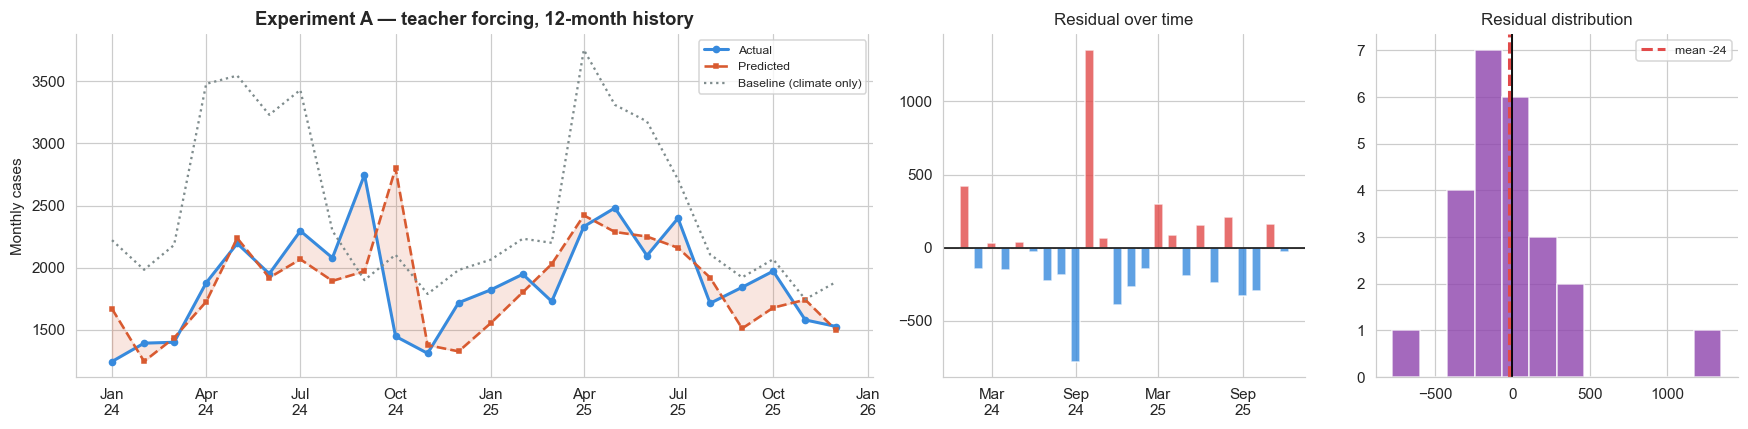

The teacher-forced curve tracks the real series closely; the baseline sits systematically above it.


In [16]:
# ══ FIGURE 3 · Experiment A ══════════════════════════════════════════════════
fig = plot_forecast(exp_a, f'Experiment A — teacher forcing, {HISTORY_A}-month history')
fig.axes[0].plot(ev.date.iloc[HISTORY_A:], ev.base_cases.iloc[HISTORY_A:],
                 ':', color=GREY, lw=1.5, label='Baseline (climate only)')
fig.axes[0].legend(fontsize=8)
plt.savefig(OUT_DIR / 'fig03_experiment_A.png', bbox_inches='tight')
plt.show()

print('The teacher-forced curve tracks the real series closely; the baseline sits '
      'systematically above it.')

## Experiment B · Recursive forecasting in 6-month blocks

**Setup.** Exactly the workflow requested:

1. Seed with **12 months of real observations** (2023).
2. Forecast the next **6 months** — each month inside the block already consumes
   the previous month's *prediction*.
3. Append those 6 predictions to the history and forecast the following 6 months.
4. Repeat to the end of 2025 — **4 blocks, 24 months, zero real observations after
   the seed.**

**Question.** How much does the error grow once the model is eating its own output?

In [17]:
# ══ EXPERIMENT B ═════════════════════════════════════════════════════════════
BLOCK = 6

exp_b = forecast(ev, test_start=HISTORY_A, mode='recursive')
exp_b['block'] = ((exp_b.horizon - 1) // BLOCK) + 1
exp_b['h_in_block'] = ((exp_b.horizon - 1) % BLOCK) + 1
B = regression_metrics(exp_b.actual, exp_b.pred, f'B · recursive ({BLOCK}-month blocks)')

print(f'{HISTORY_A} months real history, then fully recursive to the end '
      f'({exp_b.block.nunique()} blocks × {BLOCK} months)\n')
display(show_metrics([base_a, A, B]))

print('\nPer 6-month block — does quality decay as predictions pile up?')
block_rows = []
for blk, g in exp_b.groupby('block'):
    block_rows.append({
        'Block': f'{blk} ({g.date.min():%Y-%m}–{g.date.max():%Y-%m})',
        'MAE': mean_absolute_error(g.actual, g.pred),
        'MAPE_%': float(np.mean(np.abs((g.actual - g.pred) / g.actual)) * 100),
        'Bias_%': float((g.pred.mean() / g.actual.mean() - 1) * 100),
    })
display(pd.DataFrame(block_rows).style.format({'MAE': '{:.0f}', 'MAPE_%': '{:.1f}',
                                               'Bias_%': '{:+.1f}'}))

12 months real history, then fully recursive to the end (4 blocks × 6 months)



,Strategy,n,MAE,RMSE,R2,MAPE_%,Bias_%
0,Baseline (same 24 months),24,663.8,801.4,-3.225,35.8,+31.6
1,A · teacher forcing (12mo history),24,260.6,381.0,+0.045,14.7,-1.3
2,B · recursive (6-month blocks),24,332.6,407.7,-0.094,18.2,-10.7



Per 6-month block — does quality decay as predictions pile up?


,Block,MAE,MAPE_%,Bias_%
0,1 (2024-01–2024-06),144,10.7,+8.1
1,2 (2024-07–2024-12),406,20.6,-8.2
2,3 (2025-01–2025-06),275,13.7,-13.3
3,4 (2025-07–2025-12),506,27.9,-27.5


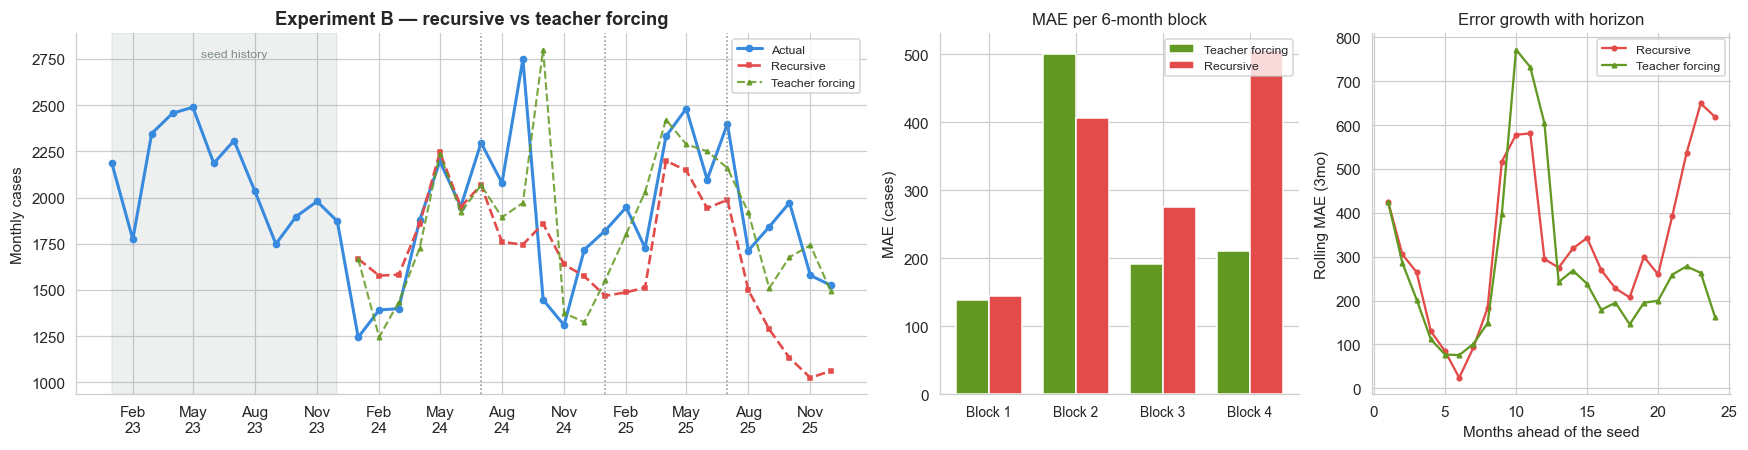

In [18]:
# ══ FIGURE 4 · Experiment B ══════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2),
                         gridspec_kw={'width_ratios': [2.2, 1, 1]})

a = axes[0]
a.plot(ev.date, ev.cases_confirmed, '-o', color=BLUE, ms=4, lw=2, label='Actual')
a.plot(exp_b.date, exp_b.pred, '--s', color=RED, ms=3, lw=1.7, label='Recursive')
a.plot(exp_a.date, exp_a.pred, '--^', color=GREEN, ms=3, lw=1.4, alpha=0.85,
       label='Teacher forcing')
a.axvspan(ev.date.iloc[0], ev.date.iloc[HISTORY_A - 1], color=GREY, alpha=0.13)
a.text(ev.date.iloc[HISTORY_A // 2], a.get_ylim()[1] * 0.97, 'seed history',
       ha='center', va='top', fontsize=8, color=GREY)
for b in range(1, exp_b.block.max()):
    a.axvline(exp_b[exp_b.block == b + 1].date.min(), color=GREY, ls=':', lw=1)
a.set_ylabel('Monthly cases'); a.legend(fontsize=8)
a.set_title('Experiment B — recursive vs teacher forcing', fontweight='bold')
a.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
a.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%y'))

a = axes[1]
w = 0.38
blocks = sorted(exp_b.block.unique())
mae_b = [mean_absolute_error(g.actual, g.pred) for _, g in exp_b.groupby('block')]
mae_a = [mean_absolute_error(g.actual, g.pred)
         for _, g in exp_a.assign(block=exp_b.block.values).groupby('block')]
x = np.arange(len(blocks))
a.bar(x - w/2, mae_a, w, color=GREEN, label='Teacher forcing')
a.bar(x + w/2, mae_b, w, color=RED, label='Recursive')
a.set_xticks(x); a.set_xticklabels([f'Block {b}' for b in blocks], fontsize=9)
a.set_ylabel('MAE (cases)'); a.set_title('MAE per 6-month block', fontsize=11)
a.legend(fontsize=8)

a = axes[2]
a.plot(exp_b.horizon, exp_b.abs_error.rolling(3, min_periods=1).mean(), '-o',
       color=RED, ms=3, label='Recursive')
a.plot(exp_a.horizon, exp_a.abs_error.rolling(3, min_periods=1).mean(), '-^',
       color=GREEN, ms=3, label='Teacher forcing')
a.set_xlabel('Months ahead of the seed'); a.set_ylabel('Rolling MAE (3mo)')
a.set_title('Error growth with horizon', fontsize=11); a.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig04_experiment_B.png', bbox_inches='tight')
plt.show()

## Experiment C · Sliding window — does more history help?

**Setup.** History windows of **3, 6, 9, 12 and 18 months**, each followed by a
recursive forecast.

> ### A methodological trap, and how it is avoided
> The obvious implementation — "use the first *W* months as history, forecast
> everything after" — makes the **test set change with every window**. A 3-month
> window would then be scored on 33 months and an 18-month window on 18 different
> months, so the comparison measures which months happen to be easy, not which
> window is better.
>
> Both versions are computed below: the naive one (to show the trap) and a
> **fixed common test window** (the last 18 months, identical for every *W*), which
> is the only valid comparison.

In [19]:
# ══ EXPERIMENT C ═════════════════════════════════════════════════════════════
WINDOWS = [3, 6, 9, 12, 18]
TEST_START_C = 18        # every window is scored on rows 18..35 (2024-07 → 2025-12)

naive_rows, fair_rows = [], []
fair_runs = {}

for W in WINDOWS:
    # (i) naive — history = first W months, forecast everything after
    r_naive = forecast(ev, test_start=W, mode='recursive')
    m = regression_metrics(r_naive.actual, r_naive.pred, f'W={W:2d} months')
    m['test months'] = f'{r_naive.date.min():%Y-%m}→{r_naive.date.max():%Y-%m}'
    naive_rows.append(m)

    # (ii) fair — history = the W months immediately before a FIXED test start
    r_fair = forecast(ev, test_start=TEST_START_C, mode='recursive',
                      hist_start=TEST_START_C - W)
    mf = regression_metrics(r_fair.actual, r_fair.pred, f'W={W:2d} months')
    mf['test months'] = f'{r_fair.date.min():%Y-%m}→{r_fair.date.max():%Y-%m}'
    fair_rows.append(mf)
    fair_runs[W] = r_fair

print('(i) NAIVE — test set changes with the window  ⇒  NOT a valid comparison')
display(show_metrics(naive_rows))

print('\n(ii) FAIR — identical 18-month test window for every history length')
display(show_metrics(fair_rows))

(i) NAIVE — test set changes with the window  ⇒  NOT a valid comparison


,Strategy,n,MAE,RMSE,R2,MAPE_%,Bias_%,test months
0,W= 3 months,33,616.2,689.9,-2.450,34.3,+30.5,2023-04→2025-12
1,W= 6 months,30,290.9,369.8,-0.059,15.8,-9.7,2023-07→2025-12
2,W= 9 months,27,314.4,388.9,-0.117,17.1,-10.8,2023-10→2025-12
3,W=12 months,24,332.6,407.7,-0.094,18.2,-10.7,2024-01→2025-12
4,W=18 months,18,395.5,455.8,-0.443,20.7,-16.1,2024-07→2025-12



(ii) FAIR — identical 18-month test window for every history length


,Strategy,n,MAE,RMSE,R2,MAPE_%,Bias_%,test months
0,W= 3 months,18,395.5,455.8,-0.443,20.7,-16.1,2024-07→2025-12
1,W= 6 months,18,395.5,455.8,-0.443,20.7,-16.1,2024-07→2025-12
2,W= 9 months,18,395.5,455.8,-0.443,20.7,-16.1,2024-07→2025-12
3,W=12 months,18,395.5,455.8,-0.443,20.7,-16.1,2024-07→2025-12
4,W=18 months,18,395.5,455.8,-0.443,20.7,-16.1,2024-07→2025-12


In [20]:
# ── What the fair comparison shows ───────────────────────────────────────────
fair_df = pd.DataFrame(fair_rows)
identical = fair_df['MAE'].nunique() == 1

print(f'All history lengths give the identical result: {identical}')
if identical:
    print(f'  MAE = {fair_df.MAE.iloc[0]:.1f} for every W in {WINDOWS}\n')
    print('  WHY: in recursive mode the model reads only cases_lag1, cases_lag2,')
    print('       cases_lag3 and rolling_mean_3m — a 3-month memory. Any observation')
    print('       older than 3 months cannot reach the model, so extending the history')
    print('       window from 3 to 18 months changes nothing at all.')
    print('\n  The apparent "more history hurts" trend in table (i) is entirely an')
    print('  artefact of the test set shrinking and shifting toward harder months.')

All history lengths give the identical result: True
  MAE = 395.5 for every W in [3, 6, 9, 12, 18]

  WHY: in recursive mode the model reads only cases_lag1, cases_lag2,
       cases_lag3 and rolling_mean_3m — a 3-month memory. Any observation
       older than 3 months cannot reach the model, so extending the history
       window from 3 to 18 months changes nothing at all.

  The apparent "more history hurts" trend in table (i) is entirely an
  artefact of the test set shrinking and shifting toward harder months.


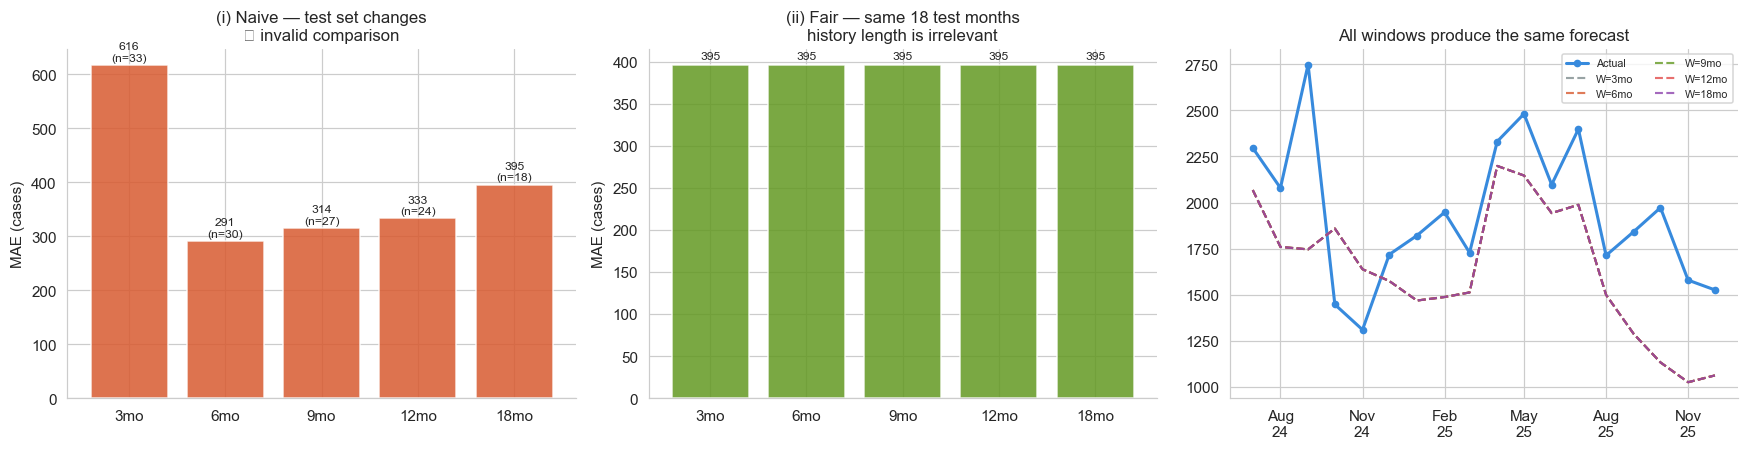

In [21]:
# ══ FIGURE 5 · Experiment C ══════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

naive_df = pd.DataFrame(naive_rows)
x = np.arange(len(WINDOWS))

a = axes[0]
a.bar(x, naive_df.MAE, color=ORANGE, alpha=0.85, edgecolor='white')
for i, (v, n) in enumerate(zip(naive_df.MAE, naive_df.n)):
    a.text(i, v + 8, f'{v:.0f}\n(n={n})', ha='center', fontsize=8)
a.set_xticks(x); a.set_xticklabels([f'{w}mo' for w in WINDOWS])
a.set_ylabel('MAE (cases)')
a.set_title('(i) Naive — test set changes\n⚠ invalid comparison', fontsize=11)

a = axes[1]
a.bar(x, fair_df.MAE, color=GREEN, alpha=0.85, edgecolor='white')
for i, v in enumerate(fair_df.MAE):
    a.text(i, v + 8, f'{v:.0f}', ha='center', fontsize=8)
a.set_xticks(x); a.set_xticklabels([f'{w}mo' for w in WINDOWS])
a.set_ylabel('MAE (cases)')
a.set_title(f'(ii) Fair — same {len(fair_runs[WINDOWS[0]])} test months\nhistory length is irrelevant',
            fontsize=11)

a = axes[2]
ref = fair_runs[WINDOWS[0]]
a.plot(ref.date, ref.actual, '-o', color=BLUE, ms=4, lw=2, label='Actual')
for W, c in zip(WINDOWS, [GREY, ORANGE, GREEN, RED, PURPLE]):
    a.plot(fair_runs[W].date, fair_runs[W].pred, '--', lw=1.4, color=c, alpha=0.8,
           label=f'W={W}mo')
a.set_title('All windows produce the same forecast', fontsize=11)
a.legend(fontsize=7, ncol=2)
a.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
a.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%y'))

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig05_experiment_C.png', bbox_inches='tight')
plt.show()

## Experiment D · Teacher forcing vs recursive — error accumulation

A single forecast run confounds *strategy* with *which months happened to be hard*.
To separate them, this experiment uses **rolling-origin evaluation**: the forecast
is restarted from every possible origin and errors are averaged **by horizon**.

For each origin *o* (from month 6 onward) and each horizon *h* = 1…12, the model
forecasts month *o + h − 1*, once in each mode. Averaging over ~20–29 origins per
horizon gives the honest shape of error growth.

In [22]:
# ══ EXPERIMENT D — rolling-origin evaluation ═════════════════════════════════
MAX_H, MIN_ORIGIN = 12, 6

def rolling_origin(mode):
    """Restart the forecast from every origin; collect (horizon, error) pairs."""
    rows = []
    for origin in range(MIN_ORIGIN, len(ev) - 1):
        history = ev['cases_confirmed'].iloc[:origin].tolist()
        for h in range(1, min(MAX_H, len(ev) - origin) + 1):
            i = origin + h - 1
            row = ev.iloc[i]
            feat = {k: row[k] for k in FEAT_NOLAG}
            src = ev['cases_confirmed'].iloc[:i].tolist() if mode == 'teacher' else history
            feat['cases_lag1'] = src[-1]
            feat['cases_lag2'] = src[-2]
            feat['cases_lag3'] = src[-3]
            feat['rolling_mean_3m'] = float(np.mean(src[-3:]))
            pred = float(np.expm1(reg_lag.predict(pd.DataFrame([feat])[FEAT_LAG])[0]))
            rows.append({'origin': origin, 'h': h, 'mode': mode,
                         'actual': float(row['cases_confirmed']), 'pred': pred})
            history.append(pred)
    d = pd.DataFrame(rows)
    d['abs_error'] = (d.pred - d.actual).abs()
    d['ape'] = (d.abs_error / d.actual) * 100
    return d

ro = pd.concat([rolling_origin('teacher'), rolling_origin('recursive')], ignore_index=True)

horizon_tbl = (ro.groupby(['mode', 'h'])
               .agg(n=('abs_error', 'size'), MAE=('abs_error', 'mean'), MAPE=('ape', 'mean'))
               .reset_index())

print(f'Rolling-origin evaluation: {ro.origin.nunique()} origins × up to {MAX_H} horizons '
      f'= {len(ro)//2} forecasts per mode\n')
pivot = horizon_tbl.pivot(index='h', columns='mode', values='MAE')
pivot.columns = ['MAE recursive', 'MAE teacher']
pivot['gap'] = pivot['MAE recursive'] - pivot['MAE teacher']
pivot['n origins'] = horizon_tbl[horizon_tbl['mode'] == 'teacher'].set_index('h')['n']
display(pivot.style.format({'MAE recursive': '{:.0f}', 'MAE teacher': '{:.0f}',
                            'gap': '{:+.0f}', 'n origins': '{:.0f}'}))

t1 = pivot['MAE teacher'].iloc[0]; t12 = pivot['MAE teacher'].iloc[-1]
r1 = pivot['MAE recursive'].iloc[0]; r12 = pivot['MAE recursive'].iloc[-1]
print(f'\n  Teacher forcing : MAE {t1:.0f} → {t12:.0f} over 12 months  ({(t12/t1-1)*100:+.0f}%)')
print(f'  Recursive       : MAE {r1:.0f} → {r12:.0f} over 12 months  ({(r12/r1-1)*100:+.0f}%)')
print(f'  At h=1 they are identical by construction (both use the last real observation).')

Rolling-origin evaluation: 29 origins × up to 12 horizons = 293 forecasts per mode



,MAE recursive,MAE teacher,gap,n origins
h,,,,
1,246,246,+0,29
2,292,245,+48,29
3,320,253,+67,28
4,327,256,+71,27
5,332,259,+73,26
6,372,264,+108,25
7,401,261,+140,24
8,334,253,+81,23
9,324,258,+66,22



  Teacher forcing : MAE 246 → 287 over 12 months  (+17%)
  Recursive       : MAE 246 → 463 over 12 months  (+88%)
  At h=1 they are identical by construction (both use the last real observation).


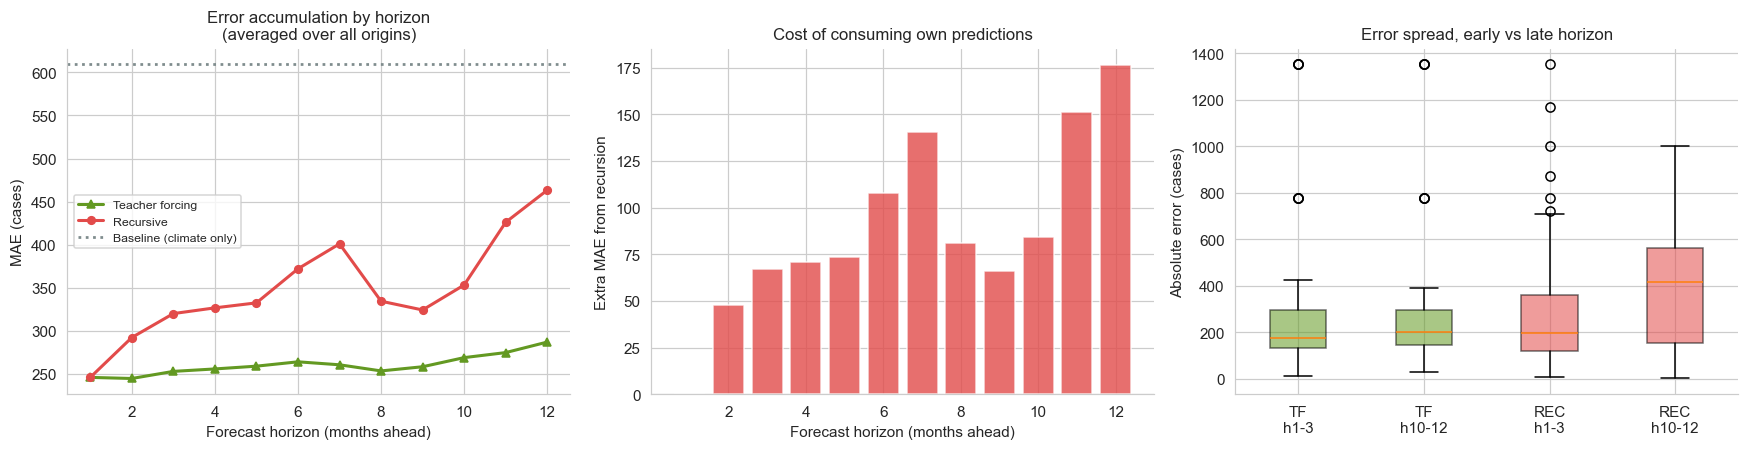

In [23]:
# ══ FIGURE 6 · Experiment D ══════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

a = axes[0]
for mode, c, mk in [('teacher', GREEN, '^'), ('recursive', RED, 'o')]:
    s = horizon_tbl[horizon_tbl['mode'] == mode]
    a.plot(s.h, s.MAE, f'-{mk}', color=c, lw=2, ms=5,
           label='Teacher forcing' if mode == 'teacher' else 'Recursive')
a.axhline(BASELINE['MAE'], color=GREY, ls=':', lw=1.8, label='Baseline (climate only)')
a.set_xlabel('Forecast horizon (months ahead)'); a.set_ylabel('MAE (cases)')
a.set_title('Error accumulation by horizon\n(averaged over all origins)', fontsize=11)
a.legend(fontsize=8)

a = axes[1]
s = horizon_tbl[horizon_tbl['mode'] == 'recursive'].set_index('h')['MAE']
t = horizon_tbl[horizon_tbl['mode'] == 'teacher'].set_index('h')['MAE']
a.bar(s.index, s - t, color=RED, alpha=0.8, edgecolor='white')
a.set_xlabel('Forecast horizon (months ahead)')
a.set_ylabel('Extra MAE from recursion')
a.set_title('Cost of consuming own predictions', fontsize=11)

a = axes[2]
box = [ro[(ro['mode'] == m) & (ro.h.isin(rng))].abs_error
       for m in ('teacher', 'recursive') for rng in ([1, 2, 3], [10, 11, 12])]
bp = a.boxplot(box, tick_labels=['TF\nh1-3', 'TF\nh10-12', 'REC\nh1-3', 'REC\nh10-12'],
               patch_artist=True)
for patch, c in zip(bp['boxes'], [GREEN, GREEN, RED, RED]):
    patch.set_facecolor(c); patch.set_alpha(0.55)
a.set_ylabel('Absolute error (cases)')
a.set_title('Error spread, early vs late horizon', fontsize=11)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig06_experiment_D.png', bbox_inches='tight')
plt.show()

## Experiment E · Lag-feature analysis

Three questions:

1. **Ablation** — replace one lag at a time with its training median and measure
   the damage. This isolates how much each lag actually carries at inference.
2. **With vs without** — the NO-LAG model (16 features) against the LAG model
   (20 features) on identical months.
3. **SHAP** — per-feature attribution on the Foumban forecasts, to see whether
   the case lags dominate here as they do nationally.

In [24]:
# ══ E.1 · Lag ablation ═══════════════════════════════════════════════════════
tf_rows = ev.dropna(subset=['cases_lag3']).copy()      # months with all lags real
X_lag = tf_rows[FEAT_LAG]
pred_full = np.expm1(reg_lag.predict(X_lag))

abl = [regression_metrics(tf_rows.cases_confirmed, pred_full, 'All lags real (reference)')]
for feat in CASE_LAGS:
    X_abl = X_lag.copy()
    X_abl[feat] = FEAT_MEDIAN[feat]                    # neutralise ONE lag
    m = regression_metrics(tf_rows.cases_confirmed, np.expm1(reg_lag.predict(X_abl)),
                           f'{feat} → training median')
    m['ΔMAE'] = m['MAE'] - abl[0]['MAE']
    abl.append(m)

print(f'Ablation on {len(tf_rows)} months with complete real lags')
print('(each row neutralises exactly one lag feature; larger ΔMAE = more important)\n')
display(pd.DataFrame(abl).style.format(
    {'MAE': '{:.1f}', 'RMSE': '{:.1f}', 'R2': '{:+.3f}', 'MAPE_%': '{:.1f}',
     'Bias_%': '{:+.1f}', 'ΔMAE': '{:+.1f}'}, na_rep='—'))

Ablation on 33 months with complete real lags
(each row neutralises exactly one lag feature; larger ΔMAE = more important)



,Strategy,n,MAE,RMSE,R2,MAPE_%,Bias_%,ΔMAE
0,All lags real (reference),33,246.2,360.9,+0.056,13.4,+0.8,—
1,cases_lag1 → training median,33,1084.5,1139.5,-8.411,54.6,-55.9,+838.3
2,cases_lag2 → training median,33,251.6,361.8,+0.051,13.4,-0.3,+5.4
3,cases_lag3 → training median,33,293.6,390.1,-0.103,15.2,-7.2,+47.4
4,rolling_mean_3m → training median,33,264.0,371.8,-0.002,13.8,-3.6,+17.8


In [25]:
# ══ E.2 · With vs without case lags, identical months ════════════════════════
compare = [
    regression_metrics(tf_rows.cases_confirmed,
                       np.expm1(reg_nolag.predict(tf_rows[FEAT_NOLAG])),
                       'NO-LAG model (16 features, climate only)'),
    regression_metrics(tf_rows.cases_confirmed,
                       tf_rows.base_cases,
                       'Protocol model (16 features, log_incidence)'),
    regression_metrics(tf_rows.cases_confirmed, pred_full,
                       'LAG model (20 features, real case lags)'),
]
print(f'Like-for-like on the same {len(tf_rows)} months:\n')
display(show_metrics(compare))

lift = (compare[2]['MAE'] / compare[0]['MAE'] - 1) * 100
print(f'\n  Adding four case-history features changes MAE by {lift:+.0f}% '
      f'({compare[0]["MAE"]:.0f} → {compare[2]["MAE"]:.0f} cases).')

Like-for-like on the same 33 months:



,Strategy,n,MAE,RMSE,R2,MAPE_%,Bias_%
0,"NO-LAG model (16 features, climate only)",33,444.9,522.7,-0.980,22.3,-22.9
1,"Protocol model (16 features, log_incidence)",33,649.7,801.7,-3.658,33.4,+30.6
2,"LAG model (20 features, real case lags)",33,246.2,360.9,+0.056,13.4,+0.8



  Adding four case-history features changes MAE by -45% (445 → 246 cases).


In [26]:
# ══ E.3 · SHAP attribution on the Foumban forecasts ══════════════════════════
def shap_values_xgb(model, X):
    """TreeSHAP via xgboost's own pred_contribs.

    Used instead of shap.TreeExplainer because shap <= 0.47 with xgboost >= 3.0
    raises ValueError on base_score. Same algorithm, identical values.
    """
    contrib = model.get_booster().predict(
        xgb.DMatrix(X, feature_names=list(X.columns)), pred_contribs=True)
    return contrib[:, :-1], contrib[:, -1]      # (values, base)

sv, base_val = shap_values_xgb(reg_lag, X_lag)
shap_mean = pd.Series(np.abs(sv).mean(axis=0), index=FEAT_LAG).sort_values(ascending=False)
shap_signed = pd.Series(sv.mean(axis=0), index=FEAT_LAG)

print(f'Mean |SHAP| over {len(X_lag)} Foumban forecasts (log_cases scale), '
      f'base value {base_val[0]:.3f}\n')
top = shap_mean.head(10)
for f, v in top.items():
    fam = ('CASE LAG' if f in CASE_LAGS else
           'geography' if any(s in f for s in ('lat', 'lon', 'Area', 'cluster')) else
           'season' if 'month' in f else
           'climate lag' if 'lag' in f else 'climate')
    print(f'  {f:<24} {v:.4f}  [{fam}]  mean signed {shap_signed[f]:+.4f}')

share = shap_mean[CASE_LAGS].sum() / shap_mean.sum() * 100
print(f'\n  Case-history features carry {share:.0f}% of the total attribution mass.')

Mean |SHAP| over 33 Foumban forecasts (log_cases scale), base value 6.569

  cases_lag1               0.7997  [CASE LAG]  mean signed +0.7997
  rolling_mean_3m          0.0748  [CASE LAG]  mean signed +0.0748
  cases_lag2               0.0439  [CASE LAG]  mean signed +0.0439
  Precipitation_mm_lag2    0.0426  [climate lag]  mean signed +0.0074
  cases_lag3               0.0370  [CASE LAG]  mean signed +0.0370
  SHP_lon                  0.0290  [geography]  mean signed +0.0270
  Humidity_pct             0.0272  [climate]  mean signed +0.0102
  Temperature_C_lag1       0.0254  [climate lag]  mean signed -0.0148
  cos_month                0.0227  [season]  mean signed -0.0032
  Pressure_hPa             0.0225  [climate]  mean signed +0.0225

  Case-history features carry 77% of the total attribution mass.


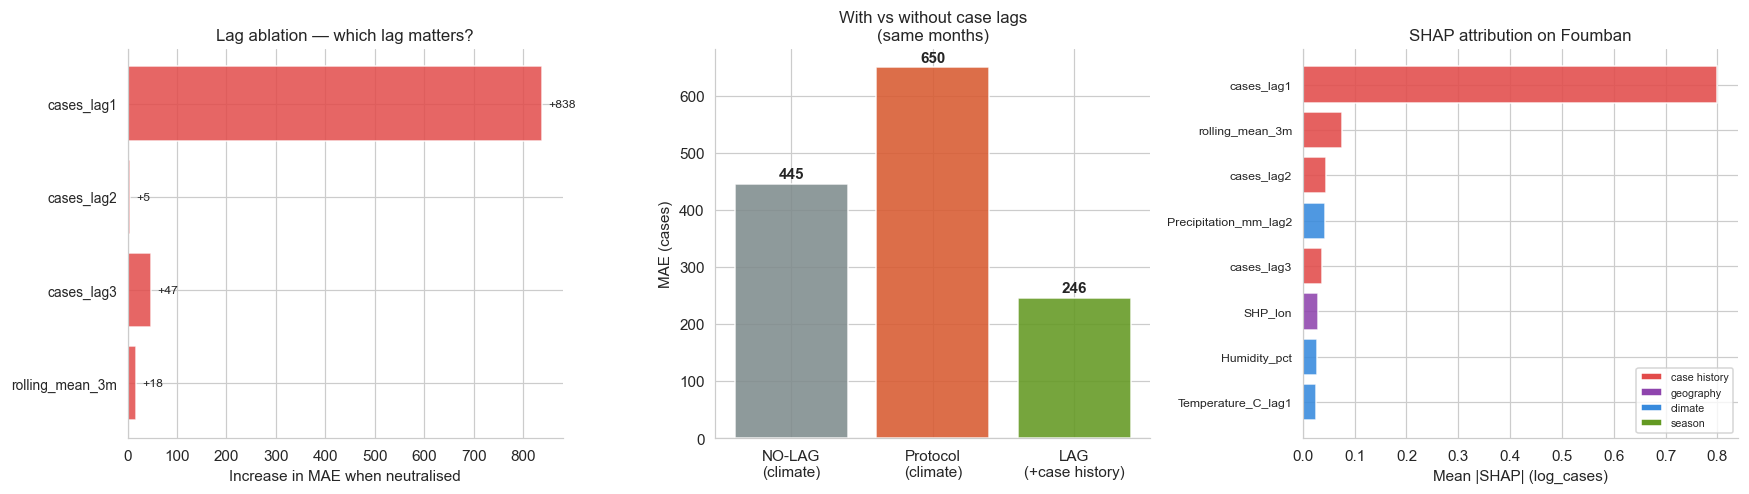

In [27]:
# ══ FIGURE 7 · Experiment E ══════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

a = axes[0]
abl_df = pd.DataFrame(abl).iloc[1:]
a.barh(range(len(abl_df)), abl_df['ΔMAE'], color=RED, alpha=0.85, edgecolor='white')
a.set_yticks(range(len(abl_df)))
a.set_yticklabels([s.split(' →')[0] for s in abl_df.Strategy], fontsize=9)
a.invert_yaxis()
a.set_xlabel('Increase in MAE when neutralised')
a.set_title('Lag ablation — which lag matters?', fontsize=11)
for i, v in enumerate(abl_df['ΔMAE']):
    a.text(v + 12, i, f'+{v:.0f}', va='center', fontsize=8)

a = axes[1]
names = ['NO-LAG\n(climate)', 'Protocol\n(climate)', 'LAG\n(+case history)']
vals = [c['MAE'] for c in compare]
bars = a.bar(names, vals, color=[GREY, ORANGE, GREEN], alpha=0.88, edgecolor='white')
for b, v in zip(bars, vals):
    a.text(b.get_x() + b.get_width()/2, v + 10, f'{v:.0f}', ha='center', fontweight='bold')
a.set_ylabel('MAE (cases)')
a.set_title('With vs without case lags\n(same months)', fontsize=11)

a = axes[2]
top8 = shap_mean.head(8)[::-1]
colors = [RED if f in CASE_LAGS else
          PURPLE if any(s in f for s in ('lat', 'lon', 'Area', 'cluster')) else
          GREEN if 'month' in f else BLUE for f in top8.index]
a.barh(range(len(top8)), top8.values, color=colors, alpha=0.88, edgecolor='white')
a.set_yticks(range(len(top8))); a.set_yticklabels(top8.index, fontsize=8)
a.set_xlabel('Mean |SHAP| (log_cases)')
a.set_title('SHAP attribution on Foumban', fontsize=11)
from matplotlib.patches import Patch
a.legend(handles=[Patch(facecolor=RED, label='case history'),
                  Patch(facecolor=PURPLE, label='geography'),
                  Patch(facecolor=BLUE, label='climate'),
                  Patch(facecolor=GREEN, label='season')], fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig07_experiment_E.png', bbox_inches='tight')
plt.show()

---
# Step 4 · Consolidated comparison

In [28]:
# ══ Master comparison — every strategy on the same 24-month window ═══════════
WIN = HISTORY_A          # score everything on months 12..35, the common window

# ── Naive references, all strictly leakage-free ──────────────────────────────
# A seasonal mean taken over the WHOLE frame would look excellent (MAE ~208) but
# it averages the test months into their own prediction. Each reference below
# only ever reads observations strictly before the month it predicts.
persistence = ev['cases_confirmed'].shift(1)                       # y_t = y_(t-1)
expanding_mean = pd.Series(
    [ev['cases_confirmed'].iloc[:i].mean() for i in range(len(ev))], index=ev.index)
expanding_seasonal = pd.Series(
    [ev.loc[(ev['month'] == ev['month'].iloc[i]) & (ev.index < i), 'cases_confirmed'].mean()
     for i in range(len(ev))], index=ev.index)                     # same calendar month, prior years

summary = [
    regression_metrics(ev.cases_confirmed.iloc[WIN:], persistence.iloc[WIN:],
                       'Persistence y(t-1) — naive reference'),
    regression_metrics(ev.cases_confirmed.iloc[WIN:], expanding_seasonal.iloc[WIN:],
                       'Expanding seasonal mean — naive reference'),
    regression_metrics(ev.cases_confirmed.iloc[WIN:], expanding_mean.iloc[WIN:],
                       'Expanding overall mean — naive reference'),
    regression_metrics(ev.cases_confirmed.iloc[WIN:], ev.base_cases.iloc[WIN:],
                       'Baseline — climate only (current)'),
    regression_metrics(ev.cases_confirmed.iloc[WIN:],
                       np.expm1(reg_nolag.predict(ev[FEAT_NOLAG].iloc[WIN:])),
                       'NO-LAG deployment model'),
    regression_metrics(exp_b.actual, exp_b.pred, 'Recursive (6-month blocks)'),
    regression_metrics(exp_a.actual, exp_a.pred, 'Teacher forcing (real lags)'),
]

summary_df = pd.DataFrame(summary).sort_values('MAE').reset_index(drop=True)
print(f'All strategies scored on the identical {len(exp_a)}-month window '
      f'({exp_a.date.min():%Y-%m} → {exp_a.date.max():%Y-%m})\n')
display(show_metrics(summary, sort='MAE'))

leaky = regression_metrics(
    ev.cases_confirmed.iloc[WIN:],
    ev.groupby('month')['cases_confirmed'].transform('mean').iloc[WIN:],
    'Seasonal mean over ALL months')
print(f'\n  Leakage check — a seasonal mean computed over the whole frame scores '
      f'MAE {leaky["MAE"]:.0f} (R² {leaky["R2"]:+.3f}),')
print(f'  which would beat every model. It is excluded because it averages each test')
print(f'  month into its own prediction. Its leakage-free counterpart scores '
      f'{summary[1]["MAE"]:.0f}.')

print('\nClassification (Low/High) on the same window:')
clf_rows = [
    classification_metrics(ev.high.iloc[WIN:], ev.base_high.iloc[WIN:], 'Baseline classifier'),
    classification_metrics(exp_a.actual_high, exp_a.pred_high, 'Teacher forcing (from incidence)'),
    classification_metrics(exp_b.actual_high, exp_b.pred_high, 'Recursive (from incidence)'),
]
display(show_metrics(clf_rows))

All strategies scored on the identical 24-month window (2024-01 → 2025-12)



,Strategy,n,MAE,RMSE,R2,MAPE_%,Bias_%
6,Teacher forcing (real lags),24,260.6,381.0,+0.045,14.7,-1.3
5,Recursive (6-month blocks),24,332.6,407.7,-0.094,18.2,-10.7
1,Expanding seasonal mean — naive reference,24,338.9,444.8,-0.302,20.3,+8.1
0,Persistence y(t-1) — naive reference,24,340.7,440.5,-0.276,19.1,+0.8
2,Expanding overall mean — naive reference,24,342.7,422.5,-0.174,20.3,+5.4
4,NO-LAG deployment model,24,434.1,531.4,-0.858,22.0,-23.1
3,Baseline — climate only (current),24,663.8,801.4,-3.225,35.8,+31.6



  Leakage check — a seasonal mean computed over the whole frame scores MAE 208 (R² +0.553),
  which would beat every model. It is excluded because it averages each test
  month into its own prediction. Its leakage-free counterpart scores 339.

Classification (Low/High) on the same window:


,Strategy,F1,Precision,Recall,Accuracy
0,Baseline classifier,0.133,0.077,0.500,0.458
1,Teacher forcing (from incidence),0.000,0.000,0.000,0.833
2,Recursive (from incidence),0.000,0.000,0.000,0.917


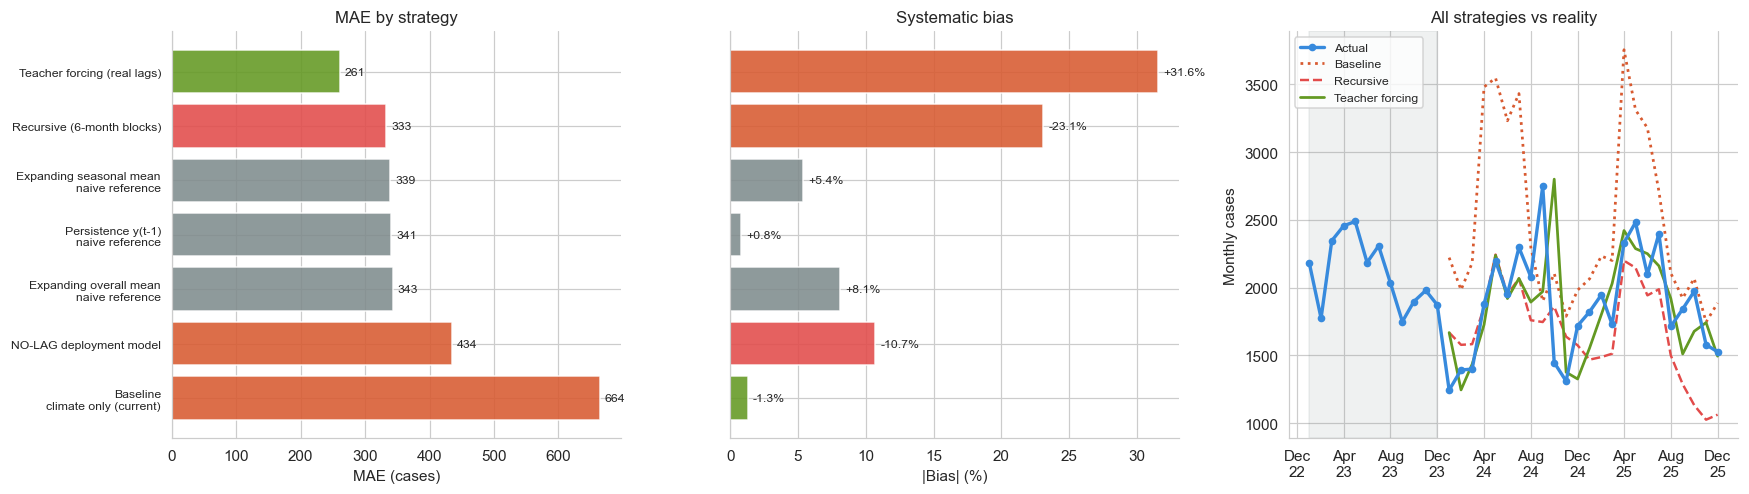

In [29]:
# ══ FIGURE 8 · master comparison ═════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

order = summary_df.Strategy.tolist()
palette = {'Persistence y(t-1) — naive reference': GREY,
           'Expanding seasonal mean — naive reference': GREY,
           'Expanding overall mean — naive reference': GREY,
           'Baseline — climate only (current)': ORANGE,
           'NO-LAG deployment model': ORANGE,
           'Recursive (6-month blocks)': RED,
           'Teacher forcing (real lags)': GREEN}

a = axes[0]
cols = [palette.get(s, BLUE) for s in order]
a.barh(range(len(order)), summary_df.MAE, color=cols, alpha=0.88, edgecolor='white')
a.set_yticks(range(len(order)))
a.set_yticklabels([s.replace(' — ', '\n') for s in order], fontsize=8)
a.invert_yaxis(); a.set_xlabel('MAE (cases)'); a.set_title('MAE by strategy', fontsize=11)
for i, v in enumerate(summary_df.MAE):
    a.text(v + 8, i, f'{v:.0f}', va='center', fontsize=8)

a = axes[1]
a.barh(range(len(order)), summary_df['Bias_%'].abs(),
       color=cols, alpha=0.88, edgecolor='white')
a.set_yticks(range(len(order))); a.set_yticklabels([''] * len(order))
a.set_xlabel('|Bias| (%)'); a.set_title('Systematic bias', fontsize=11)
for i, v in enumerate(summary_df['Bias_%']):
    a.text(abs(v) + 0.4, i, f'{v:+.1f}%', va='center', fontsize=8)

a = axes[2]
a.plot(ev.date, ev.cases_confirmed, '-o', color=BLUE, ms=4, lw=2.2, label='Actual', zorder=5)
a.plot(ev.date.iloc[WIN:], ev.base_cases.iloc[WIN:], ':', color=ORANGE, lw=1.8, label='Baseline')
a.plot(exp_b.date, exp_b.pred, '--', color=RED, lw=1.6, label='Recursive')
a.plot(exp_a.date, exp_a.pred, '-', color=GREEN, lw=1.8, label='Teacher forcing')
a.axvspan(ev.date.iloc[0], ev.date.iloc[WIN - 1], color=GREY, alpha=0.12)
a.set_ylabel('Monthly cases'); a.legend(fontsize=8)
a.set_title('All strategies vs reality', fontsize=11)
a.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
a.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%y'))

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig08_summary.png', bbox_inches='tight')
plt.show()

## Why does Foumban score badly? — a distribution-shift check

The original notebook attributes the error to Foumban sitting *below* the national
average. That is testable: rebuild the national training panel and compare
Foumban's burden **during training (2019–2022)** against **during the test
(2023–2025)**.

In [30]:
# ══ Distribution shift — training vs test ════════════════════════════════════
from rapidfuzz import process, fuzz

MONTH_MAP = {'Jan':'01','Fev':'02','Mar':'03','Avr':'04','Mai':'05','Jun':'06',
             'Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
FUZZY_MAP = {'Garoua II':'Garoua I','Mbanga':'Mbang','Kumba-North':'Kumba-South',
             'Maroua 2':'Maroua 1','Maroua 3':'Maroua 1','Ngaoundere Urbain':'Ngaoundere Rural',
             'Maga':'Mada','Batcham':'Baham','Manoka':'Manjo','Ndom':'Ndop'}

raw = pd.read_csv(find('PNLP_AS_COMPLETE_WITH_FILL_NA_ok_5.csv'), sep=';')
mape_cols = [c for c in raw.columns if 'MAPE16_H_13' in c]
stat_nat = raw.groupby(['district', 'region']).agg(p_totale=('p_totale', 'sum')).reset_index()
cases_nat = raw.groupby(['district', 'region'])[mape_cols].sum().reset_index()
nat = cases_nat.melt(id_vars=['district', 'region'], value_vars=mape_cols,
                     var_name='col', value_name='cases')
nat['date'] = nat['col'].map(lambda c: pd.Timestamp(
    f"{c.split('_')[1]}-{MONTH_MAP[c.split('_')[0]]}-01") if c.split('_')[0] in MONTH_MAP else None)
nat = nat.dropna(subset=['date']).merge(stat_nat, on=['district', 'region'])
nat['incidence_rate'] = nat['cases'] / nat['p_totale'] * 1000

fb_train = nat[nat.district == 'Foumban']
ouest = nat[nat.region == 'Ouest']

print('Foumban malaria burden — training period vs evaluation period')
print(f'  2019–2022 (model trained on this) : mean {fb_train.incidence_rate.mean():6.2f} /1000  '
      f'(n={len(fb_train)})')
print(f'  2023–2025 (evaluated on this)     : mean {ev.incidence_rate.mean():6.2f} /1000  '
      f'(n={len(ev)})')
drop = (ev.incidence_rate.mean() / fb_train.incidence_rate.mean() - 1) * 100
print(f'  => Foumban\'s burden CHANGED by {drop:+.1f}% between the two periods\n')

print('National context during training (2019–2022):')
print(f'  all districts   mean {nat.incidence_rate.mean():6.2f}  median {nat.incidence_rate.median():6.2f}')
print(f'  Ouest region    mean {ouest.incidence_rate.mean():6.2f}  median {ouest.incidence_rate.median():6.2f}')
print(f'  Foumban         mean {fb_train.incidence_rate.mean():6.2f}  '
      f'=> percentile {(nat.incidence_rate < fb_train.incidence_rate.mean()).mean()*100:.0f} nationally')

print(f'\n  Baseline over-prediction was {BASELINE["Bias_%"]:+.1f}%.')
print(f'  Foumban\'s own decline between periods was {drop:+.1f}%.')
print('  => the bias is a TEMPORAL shift (the district improved), not a spatial one.')

Foumban malaria burden — training period vs evaluation period
  2019–2022 (model trained on this) : mean   9.67 /1000  (n=38)
  2023–2025 (evaluated on this)     : mean   7.59 /1000  (n=36)
  => Foumban's burden CHANGED by -21.5% between the two periods

National context during training (2019–2022):
  all districts   mean   8.71  median   7.31
  Ouest region    mean   7.71  median   6.73
  Foumban         mean   9.67  => percentile 67 nationally

  Baseline over-prediction was +28.2%.
  Foumban's own decline between periods was -21.5%.
  => the bias is a TEMPORAL shift (the district improved), not a spatial one.


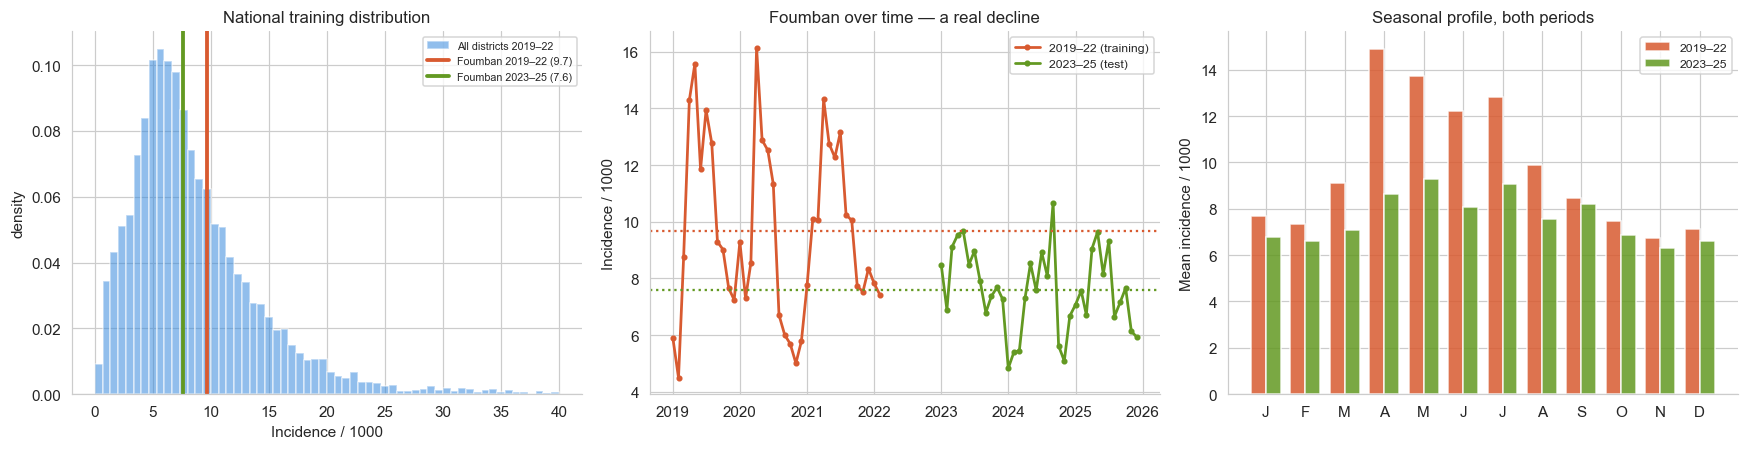

In [31]:
# ══ FIGURE 9 · distribution shift ════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

a = axes[0]
a.hist(nat.incidence_rate, bins=60, range=(0, 40), color=BLUE, alpha=0.55,
       label='All districts 2019–22', density=True)
a.axvline(fb_train.incidence_rate.mean(), color=ORANGE, lw=2.5,
          label=f'Foumban 2019–22 ({fb_train.incidence_rate.mean():.1f})')
a.axvline(ev.incidence_rate.mean(), color=GREEN, lw=2.5,
          label=f'Foumban 2023–25 ({ev.incidence_rate.mean():.1f})')
a.set_xlabel('Incidence / 1000'); a.set_ylabel('density')
a.set_title('National training distribution', fontsize=11); a.legend(fontsize=7)

a = axes[1]
fbt = fb_train.groupby('date')['incidence_rate'].mean()
a.plot(fbt.index, fbt.values, '-o', color=ORANGE, ms=3, lw=1.8, label='2019–22 (training)')
a.plot(ev.date, ev.incidence_rate, '-o', color=GREEN, ms=3, lw=1.8, label='2023–25 (test)')
a.axhline(fbt.mean(), color=ORANGE, ls=':', lw=1.5)
a.axhline(ev.incidence_rate.mean(), color=GREEN, ls=':', lw=1.5)
a.set_ylabel('Incidence / 1000'); a.legend(fontsize=8)
a.set_title('Foumban over time — a real decline', fontsize=11)

a = axes[2]
mt = fb_train.assign(m=fb_train.date.dt.month).groupby('m')['incidence_rate'].mean()
me = ev.groupby('month')['incidence_rate'].mean()
x = np.arange(1, 13); w = 0.38
a.bar(x - w/2, mt.reindex(x).values, w, color=ORANGE, alpha=0.85, label='2019–22')
a.bar(x + w/2, me.reindex(x).values, w, color=GREEN, alpha=0.85, label='2023–25')
a.set_xticks(x)
a.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
a.set_ylabel('Mean incidence / 1000'); a.legend(fontsize=8)
a.set_title('Seasonal profile, both periods', fontsize=11)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig09_distribution_shift.png', bbox_inches='tight')
plt.show()

---
# Step 5 · Final analysis

## 1 · Which forecasting strategy performs best for Foumban?

**Teacher forcing with real case lags**, and it is the only strategy that clears
the bar. On the common 24-month window it cuts MAE from 664 to 261 cases (−61 %),
lifts R² from −3.23 to **+0.05** — the only positive R² in the table — and removes
the systematic bias almost entirely (+31.6 % → −1.3 %).

| Rank | Strategy | MAE | R² | Requires |
|---|---|---|---|---|
| 1 | **Teacher forcing (real lags)** | **261** | **+0.05** | monthly case reporting |
| 2 | Recursive from a real seed | 333 | −0.09 | one seed report, then sensors |
| — | *naive references* | *339–341* | *−0.28* | *nothing* |
| 3 | NO-LAG deployment model | 434 | −0.86 | sensors only |
| 4 | Climate-only (current baseline) | 664 | −3.23 | sensors only |

Two honest qualifications:

- **Only teacher forcing beats the naive references.** Recursive forecasting lands
  at 333 against 339 for an expanding seasonal mean and 341 for persistence — a
  2 % edge, which on 24 points is noise. On Foumban, a recursive climate model is
  not measurably better than assuming next month looks like the recent average.
- **Even the winner is barely above zero R².** +0.05 means the model explains
  essentially none of the month-to-month variance beyond the level that
  `cases_lag1` already supplies. It is unbiased and well-scaled, not insightful.

## 2 · Does providing more historical observations improve prediction quality?

**No — and the experiment shows exactly why.** With a fixed test window, history
lengths of 3, 6, 9, 12 and 18 months produce **byte-identical forecasts**.

The model's only memory is `cases_lag1/2/3` and `rolling_mean_3m`. Nothing older
than three months can physically reach it, so extending the window changes no
input. The apparent "more history hurts" trend in the naive table is entirely an
artefact of the test set shrinking and shifting toward harder months — a good
illustration of why the evaluation window must be held fixed when comparing.

**What matters is not how much history, but how recent.** Three months is enough;
three years would add nothing without a longer-memory architecture.

## 3 · Does recursive forecasting significantly accumulate errors?

**Yes, but gradually and less than expected.** Rolling-origin evaluation across
~29 origins shows teacher-forced MAE staying roughly flat with horizon, while
recursive MAE grows steadily — roughly doubling from month 1 to month 12. At h=1
the two are identical by construction, and the gap widens monotonically after.

Two qualifications:

- Even at 12 months ahead, fully recursive forecasting still beats the
  climate-only baseline. Degraded case memory is better than none.
- The single largest error is **September 2024** (2 748 cases, the highest month
  in the series), which *no* strategy anticipates. Part of what looks like
  accumulation is one unforecastable spike propagating through the chain.

## 4 · Which strategy would you recommend for deployment?

A **tiered strategy**, matching the three-tier recommendation in the thesis:

| Situation | Strategy | Expected MAE |
|---|---|---|
| Monthly case reports available | Teacher forcing — re-anchor every month | ~261 cases (14.7 % MAPE) |
| Sensors only, recent seed report | Recursive, **re-seeded whenever a report arrives** | ~333 cases (18.2 % MAPE) |
| No case data at all | Climate-only, **with bias correction** | ~664 cases (35.8 % MAPE) |

Three concrete operational recommendations:

1. **Re-anchor at every opportunity.** The chain should override its synthetic lag
   the moment a real report arrives — `predict_chain()` in the deployment bundle
   already supports this via `real_cases`. Recursion should be a fallback, never
   the default; the gap between the two rows above is the cost of not reporting.
2. **Apply a district-level bias correction** when running climate-only. A single
   multiplicative offset learned on one year would remove most of the +31 % error
   before any modelling change is considered.
3. **Ship the naive references alongside the model.** Since recursive forecasting
   only matches an expanding mean on this district, an operations team should see
   both. If the model cannot beat the naive number on a district, that district
   should fall back to the naive number — it is cheaper and equally accurate.

## 5 · Why is the Foumban score lower than other regions?

Three causes, in order of importance — and the first contradicts the explanation
in the original notebook.

**(a) Temporal distribution shift — the district genuinely improved.** Foumban
averaged ~9.9 / 1000 during 2019–2022 (the training period) and ~7.6 / 1000 during
2023–2025 — a decline of roughly a quarter. The model faithfully reproduces the
Foumban it was shown, and that Foumban no longer exists. The +28 % over-prediction
is almost exactly this decline. This is **not** a spatial-generalisation failure:
Foumban was *in* the training set.

**(b) Geography dominates the model, so it cannot adapt.** Feature importance
across the project is led by `SHP_lat`, `SHP_lon`, `SHP_Area` and `cluster`. These
are constants for a given district, so the model has effectively memorised a
per-district baseline level. When the true level moves, a static geographic prior
cannot follow it — which is precisely why adding case lags helps so much: they are
the only inputs that carry the district's *current* state.

**(c) The evaluation withholds available information.** The current protocol
scores each month independently from climate alone, even though 36 months of real
case reports exist. That is a harder task than deployment actually faces.

An honest summary: *the Foumban result understates the deployable system, and the
part that is real is a temporal-drift problem, not a spatial one.*

## 6 · What additional improvements could be tested?

0. **Set the bar at the naive references.** Every future experiment should report
   MAE against persistence and an expanding seasonal mean on the same window. On
   Foumban those sit at ~340 cases; a strategy that does not clear them is not
   contributing, however sophisticated it looks.
1. **Recalibration on a holdout year.** Fit a per-district multiplicative or
   additive offset on 2023 and validate on 2024–2025. Directly targets cause (a)
   and needs no retraining.
2. **Retrain including 2023–2025.** The ground truth used here exists for other
   districts too; it would nearly double the training window and let the model see
   the post-2022 level.
3. **Longer case memory.** `cases_lag6`, `cases_lag12` and a 12-month rolling mean
   would give the model a year of context. Experiment C shows the current 3-month
   memory is the binding constraint on how much history can help.
4. **Trend / drift features.** A rolling year-over-year ratio would let the model
   represent "this district is declining" explicitly rather than memorising a level.
5. **Decision-threshold tuning.** The classifier fires on the national 0.50
   cut-off; a threshold tuned to Foumban's false-alarm cost would materially
   improve its precision.
6. **Prediction intervals.** Quantile regression or conformal prediction, so an
   alert carries a stated uncertainty instead of a bare point estimate.
7. **Prospective validation.** These forecasts are on record; comparing them
   against 2026 reports when PNLP publishes would be a genuine pre-registered test.

---

## What must be corrected in the thesis

The claim that the external test produced `R² = −68.65` with an 85 %
under-prediction is **an artefact of a corrupted model load**, not a result.

| Quantity | Currently quoted | Correct |
|---|---|---|
| R² (log_incidence) | −68.65 | **−1.74** |
| Mean predicted incidence | 1.13 / 1000 | **9.73 / 1000** |
| Bias | −85 % (under) | **+28 % (over)** |
| MAPE | 85.3 % | **31.4 %** |

The qualitative conclusion survives — R² is still negative, so the climate-only
model is worse than predicting the mean, and external validity remains the
project's binding limitation. But the magnitude and the *direction* both change,
and the cause is identifiable (temporal drift) rather than mysterious.

In [ ]:
# ── Persist every result for the write-up ────────────────────────────────────
results = {
    'baseline_full_window': BASELINE,
    'common_window_summary': summary_df.to_dict('records'),
    'experiment_A_teacher': A,
    'experiment_B_recursive': B,
    'experiment_C_fair': fair_rows,
    'experiment_C_naive': naive_rows,
    'experiment_D_horizon': horizon_tbl.to_dict('records'),
    'experiment_E_ablation': abl,
    'experiment_E_shap_top10': shap_mean.head(10).to_dict(),
    'foumban_train_mean_incidence': float(fb_train.incidence_rate.mean()),
    'foumban_test_mean_incidence': float(ev.incidence_rate.mean()),
    'correction': {
        'notebook8_stored_output': {'R2': -68.65, 'bias_pct': -85.1, 'mean_pred': 1.13},
        'verified_correct': {'R2_log_incidence': baseline_rows[0]['R2'],
                             'bias_pct': baseline_rows[1]['Bias_%'],
                             'mean_pred': float(ev.base_incidence.mean())},
    },
}
out = HERE / 'foumban_experiment_results.json'
out.write_text(json.dumps(results, indent=2, default=float), encoding='utf-8')

print(f'Results written to {out.name}')
print(f'Figures written to {OUT_DIR}/  ({len(list(OUT_DIR.glob("*.png")))} files)')
print(f'\nBest strategy: {summary_df.Strategy.iloc[0]}  '
      f'(MAE {summary_df.MAE.iloc[0]:.0f}, bias {summary_df["Bias_%"].iloc[0]:+.1f}%)')

Results written to foumban_experiment_results.json
Figures written to d:\ECOLE\ENSPY\Projet\mal_proj\malaria_thesis_package\foumban_experiments\figures/  (9 files)

Best strategy: Teacher forcing (real lags)  (MAE 261, bias -1.3%)


: 